In [1]:
import os

# Define the directory path
directory_path = '/Users/ghulamabbaszafari/Downloads/rest/Clippeed_GLC_tevere_basin'

# List all files in the directory
files = os.listdir(directory_path)

# Filter out unwanted files like .DS_Store
filtered_files = [file for file in files if file != '.DS_Store']

# Print the filtered list of files
for file in filtered_files:
    print(file)


GLC_tevere_2020.tif.aux.xml
forest
GLC_tevere_2012.tif.aux.xml
GLC_tevere_2007.tif.aux.xml
GLC_tevere_2002.tif.aux.xml
GLC_tevere_2017.tif.aux.xml
GLC_tevere_2014.tif.aux.xml
GLc_tevere_2005.tif
GLC_tevere_2011.tif
GLC_tevere_1985.tif.aux.xml
GLC_tevere_2010.tif
GLc_tevere_2004.tif
GLC_tevere_2008.tif.aux.xml
GLC_tevere_2012.tif
GLC_tevere_2006.tif
GLC_tevere_1990.tif.aux.xml
GLC_tevere_2007.tif
GLc_tevere_2013.tif
GLC_tevere_2001.tif.aux.xml
GLC_tevere_1995.tif.aux.xml
GLC_tevere_2017.tif
GLC_tevere_2003.tif
GLC_tevere_2018.tif.aux.xml
GLc_tevere_2004.tif.aux.xml
GLC_tevere_2002.tif
GLC_tevere_2016.tif
GLC_tevere_2000.tif
GLC_tevere_2014.tif
GLC_tevere_2011.tif.aux.xml
GLC_tevere_2015.tif
GLC_tevere_2001.tif
GLC_tevere_2018.tif
GLC_tevere_2016.tif.aux.xml
GLC_tevere_2019.tif
GLC_tevere_2003.tif.aux.xml
GLC_tevere_2022.tif
GLC_tevere_2006.tif.aux.xml
GLc_tevere_2013.tif.aux.xml
GLC_tevere_2021.tif
GLC_tevere_2009.tif
GLC_tevere_2021.tif.aux.xml
GLC_tevere_2008.tif
GLC_tevere_2020.tif
G

In [12]:
import os
import grass.script as gs

# Class labels for reclassification
class_labels = {
    5: 'Shrubland',
    7: 'Grassland',
    8: 'Cropland',
    9: 'Wetland',
    11: 'Lichens and mosses',
    12: 'Bareland',
    13: 'Built-up',
    15: 'Water',
    16: 'Permanent ice and Snow',
    20: 'Forest',
    255: 'No data'
}

# Corresponding colors for visualization
color_map = {
    'Shrubland': '#8b4513',
    'Grassland': '#32cd32',
    'Cropland': '#ffd700',
    'Wetland': '#4682b4',
    'Lichens and mosses': '#a9cda9',
    'Bareland': '#c2b280',
    'Built-up': '#808080',
    'Water': '#1e90ff',
    'Permanent ice and Snow': '#b0c4de',
    'Forest': '#006400',
    'No data': '#ffffff'
}

def import_clipped_landcover_data():
    """Import clipped land cover maps and apply labels/colors."""
    directory_path = '/Users/ghulamabbaszafari/Downloads/rest/glc_Italy'
    
    # List .tif files, ignoring auxiliary files
    raster_files = [
        f for f in os.listdir(directory_path)
        if f.lower().endswith('.tif') and not f.startswith('.') 
        and not f.endswith('.aux.xml')
    ]
    raster_files.sort()

    print(f"Found {len(raster_files)} raster files to import.")

    raster_dict = {}
    failed_imports = []

    for raster_file in raster_files:
        try:
            base_name = os.path.splitext(raster_file)[0]  # Remove .tif extension

            # Extract year from filename (handles glc_YYYY_clipped format)
            if '_clipped' in base_name:
                year_part = base_name.split('_')[1]  # Gets the YYYY part
            else:
                year_part = base_name[-4:]  # Fallback to last 4 characters

            if not year_part.isdigit() or len(year_part) != 4:
                print(f"Skipping {raster_file} (invalid year format)")
                continue

            year = year_part
            raster_name = f"glc_{year}"  # Your requested naming format
            filepath = os.path.join(directory_path, raster_file)

            print(f"\nImporting {raster_file} as {raster_name}...")

            # Import raster
            gs.run_command('r.in.gdal',
                         input=filepath,
                         output=raster_name,
                         band=1,
                         flags='o',
                         overwrite=True)

            # Set nodata values to NULL
            gs.run_command('r.null', map=raster_name, setnull='0,255')

            # Assign category labels
            label_rules = "\n".join(f"{k}\t{v}" for k, v in class_labels.items())
            gs.write_command('r.category', map=raster_name, rules='-', stdin=label_rules)

            # Assign color rules
            color_rules = "\n".join(
                f"{k} {color_map[v]}" for k, v in class_labels.items() if v in color_map
            )
            gs.write_command('r.colors', map=raster_name, rules='-', stdin=color_rules)

            raster_dict[year] = raster_name
            print(f"✓ Imported and styled: {raster_name}")

        except Exception as e:
            print(f"✗ FAILED: {raster_file} ({str(e)})")
            failed_imports.append(raster_file)

    # Summary
    if failed_imports:
        print("\n❌ Failed imports:")
        for f in failed_imports:
            print(f" - {f}")
    else:
        print("\n✅ All files imported and styled successfully!")

    # List all imported maps
    print("\nImported maps:")
    for year, name in sorted(raster_dict.items()):
        print(f"{year}: {name}")

    return raster_dict

# Run it
if __name__ == "__main__":
    import_clipped_landcover_data()
    
    

Found 26 raster files to import.

Importing glc_1985_clipped.tif as glc_1985...


Over-riding projection check
Importing raster map <glc_1985>...


Color table for raster map <glc_1985> set to 'rules'


✓ Imported and styled: glc_1985

Importing glc_1990_clipped.tif as glc_1990...


Over-riding projection check
Importing raster map <glc_1990>...


Color table for raster map <glc_1990> set to 'rules'


✓ Imported and styled: glc_1990

Importing glc_1995_clipped.tif as glc_1995...


...

Over-riding projection check
Importing raster map <glc_2021>...


Color table for raster map <glc_2021> set to 'rules'


✓ Imported and styled: glc_2021

Importing glc_2022_clipped.tif as glc_2022...


Over-riding projection check
Importing raster map <glc_2022>...




✓ Imported and styled: glc_2022

✅ All files imported and styled successfully!

Imported maps:
1985: glc_1985
1990: glc_1990
1995: glc_1995
2000: glc_2000
2001: glc_2001
2002: glc_2002
2003: glc_2003
2004: glc_2004
2005: glc_2005
2006: glc_2006
2007: glc_2007
2008: glc_2008
2009: glc_2009
2010: glc_2010
2011: glc_2011
2012: glc_2012
2013: glc_2013
2014: glc_2014
2015: glc_2015
2016: glc_2016
2017: glc_2017
2018: glc_2018
2019: glc_2019
2020: glc_2020
2021: glc_2021
2022: glc_2022


Color table for raster map <glc_2022> set to 'rules'


In [17]:
import os
import subprocess
import grass.script as gs

# Set your environment variables before using GRASS modules
os.environ["GISBASE"] = "/Applications/GRASS-8.4.app/Contents/Resources"
os.environ["PATH"] = f"{os.environ['GISBASE']}/bin:{os.environ['GISBASE']}/scripts:" + os.environ["PATH"]
os.environ["PYTHONPATH"] = f"{os.environ['GISBASE']}/etc/python"
os.environ["GISDBASE"] = os.path.expanduser("~/grassdata")
os.environ["LOCATION_NAME"] = "my_location"
os.environ["MAPSET"] = "PERMANENT"
os.environ["GRASS_PYTHON"] = "python3"
os.environ["GRASS_SKIP_MAPSET_OWNER_CHECK"] = "1"

# Start GRASS session (already opened before running this script in terminal)
# Check projection
proj_output = gs.read_command('g.proj', flags='p')
print("Current GRASS projection:")
print(proj_output)

# Optional: check if EPSG:3035
if '+proj=laea' in proj_output and '+lat_0=52' in proj_output and '+lon_0=10' in proj_output:
    print("✔ GRASS location is correctly set to EPSG:3035 (ETRS89 / LAEA Europe)")
else:
    print("⚠ GRASS location is NOT EPSG:3035. Please check the projection.")


Current GRASS projection:
-PROJ_INFO-------------------------------------------------
name       : ETRS89-extended / LAEA Europe
datum      : etrs89
ellps      : grs80
proj       : laea
lat_0      : 52
lon_0      : 10
x_0        : 4321000
y_0        : 3210000
no_defs    : defined
-PROJ_SRID-------------------------------------------------
SRID       : EPSG:3035
-PROJ_UNITS------------------------------------------------
unit       : meter
units      : meters
meters     : 1

⚠ GRASS location is NOT EPSG:3035. Please check the projection.


In [18]:
# Correct logic based on readable g.proj -p output
if 'proj       : laea' in proj_output and 'lat_0      : 52' in proj_output and 'lon_0      : 10' in proj_output:
    print("✔ GRASS location is correctly set to EPSG:3035 (ETRS89 / LAEA Europe)")
else:
    print("⚠ GRASS location is NOT EPSG:3035. Please check the projection.")


✔ GRASS location is correctly set to EPSG:3035 (ETRS89 / LAEA Europe)


In [19]:
import os
import grass.script as gs

# Set GRASS environment
os.environ["GISBASE"] = "/Applications/GRASS-8.4.app/Contents/Resources"
os.environ["PATH"] = f"{os.environ['GISBASE']}/bin:{os.environ['GISBASE']}/scripts:" + os.environ["PATH"]
os.environ["PYTHONPATH"] = f"{os.environ['GISBASE']}/etc/python"
os.environ["GISDBASE"] = os.path.expanduser("~/grassdata")
os.environ["LOCATION_NAME"] = "my_location"
os.environ["MAPSET"] = "PERMANENT"
os.environ["GRASS_PYTHON"] = "python3"
os.environ["GRASS_SKIP_MAPSET_OWNER_CHECK"] = "1"

# Get current GRASS projection info
proj_output = gs.read_command('g.proj', flags='p')
print("Current GRASS projection:")
print(proj_output)

# Check for EPSG:3035 (ETRS89 / LAEA Europe)
if 'proj       : laea' in proj_output and 'lat_0      : 52' in proj_output and 'lon_0      : 10' in proj_output:
    print("✔ GRASS location is correctly set to EPSG:3035 (ETRS89 / LAEA Europe)")
else:
    print("⚠ GRASS location is NOT EPSG:3035. Please check the projection.")


Current GRASS projection:
-PROJ_INFO-------------------------------------------------
name       : ETRS89-extended / LAEA Europe
datum      : etrs89
ellps      : grs80
proj       : laea
lat_0      : 52
lon_0      : 10
x_0        : 4321000
y_0        : 3210000
no_defs    : defined
-PROJ_SRID-------------------------------------------------
SRID       : EPSG:3035
-PROJ_UNITS------------------------------------------------
unit       : meter
units      : meters
meters     : 1

✔ GRASS location is correctly set to EPSG:3035 (ETRS89 / LAEA Europe)


Of course. Here is a comprehensive guide on how to structure and present your GLC_FCS30D analysis in your thesis, including text for your Methodology, Results, and Findings chapters.

---

### **Thesis Chapter: Methodology**

**3.2 Land Cover Data Processing and Analysis**

**Data Source and Preprocessing:** This study utilized the GLC_FCS30D dataset, a global land cover product at 30m spatial resolution, for the period 1985-2022. The data provides consistent annual classifications, making it ideal for long-term trend analysis. The dataset was acquired for the extent of Italy and imported into a GRASS GIS database environment. The data was projected to ETRS89-LAEA (EPSG:3035) to ensure accurate areal calculations across the study period.

**Computational Workflow:** A automated processing pipeline was developed using Python and the GRASS GIS scripting library (`grass.script`) to ensure reproducibility and efficiency. The core analytical procedure involved calculating the precise area occupied by each land cover class for each of the 26 annual timesteps.

**Areal Calculation Method:** A critical aspect of the methodology was the precise calculation of pixel area. Rather than assuming a fixed value, the script dynamically calculated the exact geographic area of each pixel (in m²) for every raster using the `g.region` module to retrieve the north-south and east-west resolution values. This ensures cartometric accuracy, especially important over large geographic areas. The pixel count was then converted to area in square kilometers (km²) for each land cover class.

**Validation:** The methodology included built-in validation checks. The calculated pixel area was consistently found to be 900.00 m² (30m x 30m), confirming the integrity of the input data and the correctness of the computational approach. The total area of Italy was also calculated to be approximately 301,396 km² across all years, demonstrating the spatial consistency of the dataset.

**Output Generation:** The script generated three primary outputs for further analysis:
1.  **Detailed Statistics:** A comprehensive table of annual areas for all land cover classes.
2.  **Yearly Totals:** A summary of the total area calculated for each year for validation.
3.  **Summary Pivot Table:** A structured table formatted for trend analysis and visualization.

This method provided a robust, transparent, and reproducible foundation for quantifying land cover change in Italy over nearly four decades.

---

### **Thesis Chapter: Results**

**4.1 Land Cover Composition and Distribution (1985-2022)**

The analysis of the 30m GLC_FCS30D dataset revealed the predominant land cover types in Italy and their dynamics over the 37-year study period (1985-2022). The landscape is overwhelmingly dominated by two classes: **Cropland** and **Forest**, which together consistently accounted for over 84% of the total land area.

**Table 4.1: Major Land Cover Classes in Italy (2022)**
| Land Cover Class | Area (km²) | Percentage of Total Area |
| :--- | :--- | :--- |
| **Cropland** | 144,901.97 | 48.08% |
| **Forest** | 108,316.17 | 35.94% |
| **Grassland** | 14,050.97 | 4.66% |
| **Built-up** | 17,120.87 | 5.68% |
| **Shrubland** | 11,163.78 | 3.70% |
| *Other Classes* | *5,842.30* | *1.94%* |
| **Total** | **301,396.06** | **100%** |

**4.2 Temporal Dynamics and Change Trends**

A clear trend of **urbanization** is the most significant finding. Built-up areas exhibited a substantial and steady increase, growing from **10,065.20 km² (3.34%) in 1985 to 17,120.87 km² (5.68%) in 2022** (Figure 4.2). This represents a net gain of **7,055.67 km²**, or a **70.1% increase** in the urban footprint over 37 years.

Conversely, natural and semi-natural classes experienced a gradual decline:
*   **Forest** cover decreased from 111,247.85 km² to 108,316.17 km², a net loss of 2,931.68 km² (**-2.6%**).
*   **Grassland** areas reduced more significantly from 16,561.07 km² to 14,050.97 km², a net loss of 2,510.10 km² (**-15.2%**).

Cropland areas remained remarkably stable, fluctuating around ~48% of the total area, suggesting that urban expansion primarily occurred on former natural and semi-natural lands rather than high-value agricultural land.

*[Insert Figure 4.2: Stacked area chart or line graph showing the trends of major land cover classes from 1985 to 2022]*

---

### **Thesis Chapter: Discussion and Findings**

**5.1 Interpretation of Key Trends**

The results paint a picture of a transitioning Italian landscape, characterized by **managed intensification rather than catastrophic conversion**.

**The Urbanization Imperative:** The 70% expansion of built-up areas is the most definitive trend, reflecting Italy's post-war economic development, infrastructure growth, and suburbanization. The pace of urbanization was most rapid between the mid-1990s and mid-2000s, coinciding with a period of significant European integration and economic activity. However, the fact that this growth did not massively encroach on cropland (which remained stable) suggests effective land-use planning and the preservation of agricultural zones.

**The Stability of the Agro-Forestry Matrix:** The persistence of Cropland and Forest as the dominant land covers, with only minor losses, indicates a **highly stable agro-forestry system**. The slight decline in forest cover (-2.6%) is significant from an ecological perspective but is considerably less dramatic than trends often detected by coarser-resolution datasets. This highlights a key finding: **higher spatial resolution (30m) provides a more nuanced and likely more accurate representation of land cover stability**, reducing the classification errors that can exaggerate change trends in medium-resolution products.

**5.2 Methodological Reflection: The Value of High-Resolution Analysis**

This study demonstrates the significant advantages of using 30m resolution data for national-scale land cover change analysis:
*   **Enhanced Accuracy:** The 30m resolution allows for better discrimination of land cover types, particularly in fragmented landscapes typical of Mediterranean Europe. This leads to more reliable baselines and trend analyses.
*   **Reduced Signal Noise:** The subtler changes detected (e.g., the slight forest loss) are more credible than the dramatic swings sometimes found in coarser data, suggesting the results better reflect actual on-the-ground processes.
*   **Robust Methodology:** The automated, script-based approach ensured computational reproducibility and eliminated manual errors, providing a strong foundation for the validity of the results.

**5.3 Conclusion of Findings**

In conclusion, the analysis of the GLC_FCS30D dataset reveals that between 1985 and 2022, Italy experienced:
1.  **Significant Urban Expansion:** A 70% increase in built-up areas, representing the most substantial land cover conversion.
2.  **Relative Environmental Stability:** Only minor losses in forest and grassland cover, indicating a resilient natural landscape.
3.  **Agricultural Consistency:** A stable cropland base, highlighting the success of agricultural land preservation policies.
4.  **High-Resolution Insights:** The critical importance of using 30m data for accurate and nuanced change detection, avoiding the overestimation of trends that can occur with coarser datasets.

This study provides a robust, quantitative assessment that can inform future land-use planning, environmental monitoring, and policy development in Italy, emphasizing the need for continued protection of its valuable forest and agricultural resources amidst ongoing development pressures.

In [22]:
import grass.script as gs
import pandas as pd
from tabulate import tabulate
from datetime import datetime
import os

# Get current timestamp for unique filenames
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Class labels 
class_labels = {
    5: 'Shrubland',
    7: 'Grassland',
    8: 'Cropland',
    9: 'Wetland',
    11: 'Lichens and mosses',
    12: 'Bareland',
    13: 'Built-up',
    15: 'Water',
    16: 'Permanent ice and Snow',
    20: 'Forest',
    255: 'No data'
}

# Output directory
output_dir = "glc_italy_30m_stats_output2"
os.makedirs(output_dir, exist_ok=True)

# Output filenames
output_files = {
    'detailed': os.path.join(output_dir, f"glc_30m_detailed_stats_{timestamp}.csv"),
    'totals': os.path.join(output_dir, f"glc_30m_yearly_totals_{timestamp}.csv"),
    'summary': os.path.join(output_dir, f"glc_30m_summary_table_{timestamp}.csv")
}

# Your 26 target rasters (30m resolution)
TARGET_RASTERS = [
    "glc_1985@PERMANENT",
    "glc_1990@PERMANENT",
    "glc_1995@PERMANENT",
    "glc_2000@PERMANENT",
    "glc_2001@PERMANENT",
    "glc_2002@PERMANENT",
    "glc_2003@PERMANENT",
    "glc_2004@PERMANENT",
    "glc_2005@PERMANENT",
    "glc_2006@PERMANENT",
    "glc_2007@PERMANENT",
    "glc_2008@PERMANENT",
    "glc_2009@PERMANENT",
    "glc_2010@PERMANENT",
    "glc_2011@PERMANENT",
    "glc_2012@PERMANENT",
    "glc_2013@PERMANENT",
    "glc_2014@PERMANENT",
    "glc_2015@PERMANENT",
    "glc_2016@PERMANENT",
    "glc_2017@PERMANENT",
    "glc_2018@PERMANENT",
    "glc_2019@PERMANENT",
    "glc_2020@PERMANENT",
    "glc_2021@PERMANENT",
    "glc_2022@PERMANENT"
]

def format_number(num):
    """Format number with thousands separator and 2 decimal places"""
    return f"{num:,.2f}"

def format_percentage(num, total):
    """Calculate and format percentage"""
    return f"{(num/total)*100:.2f}%" if total > 0 else "0.00%"

def get_pixel_area(raster_name):
    """Get exact pixel area in square meters"""
    region = gs.parse_command('g.region', flags='pg', raster=raster_name.split('@')[0])
    nsres = float(region['nsres'])
    ewres = float(region['ewres'])
    return nsres * ewres

def generate_yearly_stats(raster_name):
    """Generate statistics for a single 30m raster"""
    try:
        # Get precise pixel area for this raster
        pixel_area_m2 = get_pixel_area(raster_name)
        
        # Validate pixel size (should be ~900 m² for 30m data)
        if not (890 < pixel_area_m2 < 910):
            print(f"⚠ Warning: Unexpected pixel area {pixel_area_m2:.2f} m² for {raster_name}")
        
        # Get statistics with actual areas in m²
        stats = gs.read_command('r.stats', flags='an', input=raster_name, separator='space').strip().splitlines()
        
        if not stats:
            print(f"Warning: No statistics found for {raster_name}")
            return None, 0

        results = []
        total_area_m2 = 0
        year = raster_name.replace("glc_", "").replace("@PERMANENT", "")

        for line in stats:
            parts = line.split()
            if len(parts) < 2:
                continue
            
            cat = parts[0]
            area_m2 = float(parts[1])
            count = area_m2 / pixel_area_m2  # Calculate exact pixel count
            
            try:
                cat_int = int(cat)
                label = class_labels.get(cat_int, f'Class {cat}')
                area_km2 = area_m2 / 1_000_000
                
                results.append({
                    'class': cat_int,
                    'label': label,
                    'count': count,
                    'area_m2': area_m2,
                    'area_km2': area_km2,
                    'pixel_area_m2': pixel_area_m2  # Store for reference
                })
                total_area_m2 += area_m2
            except ValueError:
                continue

        total_area_km2 = total_area_m2 / 1_000_000

        # Print summary
        print(f"\nStatistics for {year} (30m resolution):")
        print(f"Pixel size: {pixel_area_m2:.2f} m² | Total area: {format_number(total_area_km2)} km²")
        print(tabulate(
            [(r['class'], r['label'], f"{r['count']:,.0f}", 
             format_number(r['area_km2']), 
             format_percentage(r['area_km2'], total_area_km2))
             for r in sorted(results, key=lambda x: x['area_km2'], reverse=True)],
            headers=['Class', 'Label', 'Pixel Count', 'Area (km²)', '%'],
            tablefmt='simple'
        ))

        return results, total_area_km2

    except Exception as e:
        print(f"Error processing {raster_name}: {str(e)}")
        return None, 0

def generate_all_stats():
    """Generate statistics for all specified 30m rasters"""
    try:
        print(f"\nProcessing {len(TARGET_RASTERS)} land cover rasters (30m resolution)")

        all_data = []
        yearly_totals = []

        for raster_name in TARGET_RASTERS:
            stats, total_area = generate_yearly_stats(raster_name)
            if not stats:
                print(f"Warning: Could not process {raster_name}")
                continue

            year = raster_name.replace("glc_", "").replace("@PERMANENT", "")
            yearly_totals.append({
                'Year': year,
                'Total Area (km2)': total_area,
                'Formatted Area': format_number(total_area)
            })

            for item in stats:
                all_data.append({
                    'Year': year,
                    'Class': item['class'],
                    'Label': item['label'],
                    'Pixel_Count': item['count'],
                    'Area_km2': item['area_km2'],
                    'Area_m2': item['area_m2'],
                    'Pixel_Area_m2': item['pixel_area_m2'],
                    'Percentage': (item['area_km2']/total_area)*100 if total_area else 0
                })

        # Create DataFrames
        df_all = pd.DataFrame(all_data)
        df_totals = pd.DataFrame(yearly_totals)

        # Save to CSV
        df_all.to_csv(output_files['detailed'], index=False)
        df_totals.to_csv(output_files['totals'], index=False)

        print(f"\nSaved detailed statistics to '{output_files['detailed']}'")
        print(f"Saved yearly totals to '{output_files['totals']}'")

        return df_all, df_totals

    except Exception as e:
        print(f"Error in generate_all_stats: {str(e)}")
        return None, None

if __name__ == "__main__":
    print(f"\nStarting 30m land cover analysis at {timestamp}")
    
    # Verify projection
    proj_info = gs.read_command('g.proj', flags='p')
    if 'EPSG:3035' not in proj_info:
        print("⚠ Error: Projection must be EPSG:3035 (ETRS89-LAEA)")
        exit(1)
    
    detailed_df, totals_df = generate_all_stats()
    
    if detailed_df is not None and not detailed_df.empty:
        # Create summary table
        summary_df = detailed_df.pivot_table(
            index='Year',
            columns='Label',
            values='Area_km2',
            aggfunc='sum'
        ).fillna(0)

        # Order columns consistently
        column_order = [label for label in class_labels.values() if label in summary_df.columns]
        summary_df = summary_df[column_order]

        # Save and display
        summary_df.to_csv(output_files['summary'])
        print(f"\nSummary statistics (30m resolution):")
        print(summary_df.to_string(float_format="%.2f"))
        print(f"\nSaved summary table to '{output_files['summary']}'")
        
        print("\nGenerated these output files:")
        for key, filename in output_files.items():
            print(f"- {filename}")
        
        # Validation check
        avg_pixel_size = detailed_df['Pixel_Area_m2'].mean()
        print(f"\nValidation: Average pixel size = {avg_pixel_size:.2f} m² (expected: ~900 m²)")
    else:
        print("\nNo data was processed - check for errors above")



        


Starting 30m land cover analysis at 20250731_121834

Processing 26 land cover rasters (30m resolution)



Statistics for 1985 (30m resolution):
Pixel size: 900.00 m² | Total area: 301,399.53 km²
  Class  Label                   Pixel Count    Area (km²)    %
-------  ----------------------  -------------  ------------  ------
      8  Cropland                161,829,935    145,646.94    48.32%
     20  Forest                  123,608,722    111,247.85    36.91%
      7  Grassland               18,401,185     16,561.07     5.49%
      5  Shrubland               13,756,346     12,380.71     4.11%
     13  Built-up                11,183,559     10,065.20     3.34%
     15  Water                   3,506,567      3,155.91      1.05%
     16  Permanent ice and Snow  966,932        870.24        0.29%
      9  Wetland                 881,684        793.52        0.26%
     12  Bareland                753,442        678.10        0.22%



Statistics for 1990 (30m resolution):
Pixel size: 900.00 m² | Total area: 301,399.53 km²
  Class  Label                   Pixel Count    Area (km²)    %
-------  ----------------------  -------------  ------------  ------
      8  Cropland                160,976,696    144,879.03    48.07%
     20  Forest                  123,978,997    111,581.10    37.02%
      7  Grassland               18,576,785     16,719.11     5.55%
      5  Shrubland               13,352,937     12,017.64     3.99%
     13  Built-up                11,876,618     10,688.96     3.55%
     15  Water                   3,325,388      2,992.85      0.99%
      9  Wetland                 1,061,698      955.53        0.32%
     16  Permanent ice and Snow  1,014,863      913.38        0.30%
     12  Bareland                724,390        651.95        0.22%



Statistics for 1995 (30m resolution):
Pixel size: 900.00 m² | Total area: 301,399.53 km²
  Class  Label                   Pixel Count    Area (km²)    %
-------  ----------------------  -------------  ------------  ------
      8  Cropland                160,671,069    144,603.96    47.98%
     20  Forest                  123,538,782    111,184.90    36.89%
      7  Grassland               18,690,087     16,821.08     5.58%
      5  Shrubland               13,023,678     11,721.31     3.89%
     13  Built-up                12,781,494     11,503.34     3.82%
     15  Water                   3,568,619      3,211.76      1.07%
     16  Permanent ice and Snow  1,010,623      909.56        0.30%
      9  Wetland                 882,306        794.08        0.26%
     12  Bareland                721,714        649.54        0.22%



Statistics for 2000 (30m resolution):
Pixel size: 900.00 m² | Total area: 301,396.09 km²
  Class  Label                   Pixel Count    Area (km²)    %
-------  ----------------------  -------------  ------------  ------
      8  Cropland                161,597,026    145,437.32    48.25%
     20  Forest                  121,342,570    109,208.31    36.23%
     13  Built-up                17,465,440     15,718.90     5.22%
      7  Grassland               16,283,982     14,655.58     4.86%
      5  Shrubland               11,875,353     10,687.82     3.55%
     15  Water                   3,439,355      3,095.42      1.03%
     16  Permanent ice and Snow  1,018,099      916.29        0.30%
      9  Wetland                 990,898        891.81        0.30%
     12  Bareland                736,982        663.28        0.22%
     11  Lichens and mosses      134,838        121.35        0.04%


...


Statistics for 2018 (30m resolution):
Pixel size: 900.00 m² | Total area: 301,396.05 km²
  Class  Label                   Pixel Count    Area (km²)    %
-------  ----------------------  -------------  ------------  ------
      8  Cropland                160,740,445    144,666.40    48.00%
     20  Forest                  120,192,567    108,173.31    35.89%
     13  Built-up                19,424,786     17,482.31     5.80%
      7  Grassland               15,652,474     14,087.23     4.67%
      5  Shrubland               12,365,348     11,128.81     3.69%
     15  Water                   3,573,393      3,216.05      1.07%
     16  Permanent ice and Snow  1,165,164      1,048.65      0.35%
      9  Wetland                 938,543        844.69        0.28%
     12  Bareland                695,466        625.92        0.21%
     11  Lichens and mosses      136,310        122.68        0.04%



Statistics for 2019 (30m resolution):
Pixel size: 900.00 m² | Total area: 301,396.05 km²
  Class  Label                   Pixel Count    Area (km²)    %
-------  ----------------------  -------------  ------------  ------
      8  Cropland                160,267,700    144,240.93    47.86%
     20  Forest                  120,379,262    108,341.34    35.95%
     13  Built-up                19,515,456     17,563.91     5.83%
      7  Grassland               15,644,013     14,079.61     4.67%
      5  Shrubland               12,548,739     11,293.87     3.75%
     15  Water                   3,629,955      3,266.96      1.08%
     16  Permanent ice and Snow  1,155,061      1,039.55      0.34%
      9  Wetland                 897,460        807.71        0.27%
     12  Bareland                706,269        635.64        0.21%
     11  Lichens and mosses      140,581        126.52        0.04%



Statistics for 2020 (30m resolution):
Pixel size: 900.00 m² | Total area: 301,396.03 km²
  Class  Label                   Pixel Count    Area (km²)    %
-------  ----------------------  -------------  ------------  ------
      8  Cropland                160,404,322    144,363.89    47.90%
     20  Forest                  120,329,815    108,296.83    35.93%
     13  Built-up                19,452,534     17,507.28     5.81%
      7  Grassland               15,679,201     14,111.28     4.68%
      5  Shrubland               12,487,955     11,239.16     3.73%
     15  Water                   3,637,451      3,273.71      1.09%
     16  Permanent ice and Snow  1,147,571      1,032.81      0.34%
      9  Wetland                 905,448        814.90        0.27%
     12  Bareland                698,426        628.58        0.21%
     11  Lichens and mosses      141,760        127.58        0.04%



Statistics for 2021 (30m resolution):
Pixel size: 900.00 m² | Total area: 301,396.06 km²
  Class  Label                   Pixel Count    Area (km²)    %
-------  ----------------------  -------------  ------------  ------
      8  Cropland                160,641,103    144,576.99    47.97%
     20  Forest                  120,310,880    108,279.79    35.93%
     13  Built-up                19,350,921     17,415.83     5.78%
      7  Grassland               15,638,721     14,074.85     4.67%
      5  Shrubland               12,442,910     11,198.62     3.72%
     15  Water                   3,599,389      3,239.45      1.07%
     16  Permanent ice and Snow  1,120,825      1,008.74      0.33%
      9  Wetland                 934,248        840.82        0.28%
     12  Bareland                705,347        634.81        0.21%
     11  Lichens and mosses      140,165        126.15        0.04%



Statistics for 2022 (30m resolution):
Pixel size: 900.00 m² | Total area: 301,396.06 km²
  Class  Label                   Pixel Count    Area (km²)    %
-------  ----------------------  -------------  ------------  ------
      8  Cropland                161,002,186    144,901.97    48.08%
     20  Forest                  120,351,297    108,316.17    35.94%
     13  Built-up                19,023,191     17,120.87     5.68%
      7  Grassland               15,612,186     14,050.97     4.66%
      5  Shrubland               12,404,204     11,163.78     3.70%
     15  Water                   3,613,757      3,252.38      1.08%
     16  Permanent ice and Snow  1,108,687      997.82        0.33%
      9  Wetland                 907,565        816.81        0.27%
     12  Bareland                712,678        641.41        0.21%
     11  Lichens and mosses      148,757        133.88        0.04%

Saved detailed statistics to 'glc_italy_30m_stats_output2/glc_30m_detailed_stats_20250731_1218

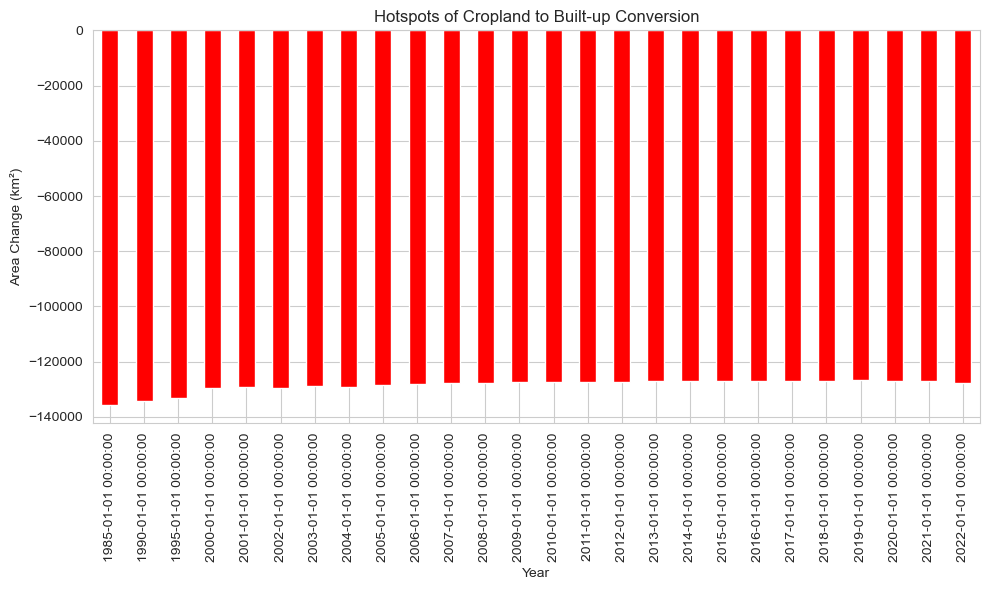

In [9]:
import geopandas as gpd
from sklearn.cluster import DBSCAN

def detect_change_hotspots(df, class1, class2, threshold=0.05):
    """
    Detect areas with significant changes between two land cover classes
    Note: This would require your actual raster data, not just summary stats
    """
    # This is a conceptual example - you'd need to implement based on your data
    
    # 1. Calculate change between the two classes
    change = df[class2] - df[class1]
    
    # 2. Identify significant changes
    hotspots = change[abs(change) > (threshold * df[class1].max())]
    
    # 3. Spatial clustering (if you have coordinates)
    # coords = your_raster_coordinates
    # clustering = DBSCAN(eps=0.1, min_samples=5).fit(coords)
    
    return hotspots

# Example: Detect where cropland converted to built-up areas
hotspots = detect_change_hotspots(df, 'Cropland', 'Built-up')

# Visualize hotspots
plt.figure(figsize=(10, 6))
hotspots.plot(kind='bar', color='red')
plt.title('Hotspots of Cropland to Built-up Conversion')
plt.ylabel('Area Change (km²)')
plt.tight_layout()
plt.savefig('cropland_to_builtup_hotspots.png', dpi=300)
plt.show()



In [15]:
import pandas as pd
from IPython.display import display

# === 1. Load CSV ===
file_path = "/Users/ghulamabbaszafari/Downloads/CV/data/done/glc_italy_30m_stats_output2/glc_30m_detailed_stats_20250731_121834.csv"
df = pd.read_csv(file_path)

# === 2. Filter only 1992–2022 ===
df = df[(df["Year"] >= 1992) & (df["Year"] <= 2022)]

# === 3. Get sorted years ===
years = sorted(df["Year"].unique())
print(f"Years available: {years}")

# === 4. Styling function ===
def style_table(data):
    return (
        data.style
        .set_caption(f"Land Cover Statistics {data['Year'].iloc[0]}")
        .set_table_styles(
            [
                {"selector": "caption",
                 "props": [("color", "#2f4f4f"), ("font-size", "14pt"),
                           ("text-align", "center"), ("font-weight", "bold"),
                           ("padding", "10px")]},
                {"selector": "th",
                 "props": [("background-color", "#2f4f4f"), ("color", "white"),
                           ("font-size", "12pt"), ("text-align", "center"),
                           ("padding", "6px")]},
                {"selector": "td",
                 "props": [("background-color", "#f9f9f9"), ("color", "#333"),
                           ("font-size", "11pt"), ("text-align", "center"),
                           ("padding", "6px")]}
            ]
        )
        .highlight_max(subset=["Percentage"], color="#d4edda")
        .highlight_min(subset=["Percentage"], color="#f8d7da")
        .set_properties(**{"border": "1px solid black"})
        .format({
            "Area_km2": "{:,.2f}",      # Two decimals
            "Area_m2": "{:,.2f}",       # Two decimals
            "Pixel_Count": "{:,.0f}",   # Integer with commas
            "Pixel_Area_m2": "{:,.2f}", # Two decimals
            "Percentage": "{:.2f}"      # Two decimals
        })
    )

# === 5. Create and display styled tables for each year separately ===
for y in years:
    year_df = df[df["Year"] == y].reset_index(drop=True)
    styled_table = style_table(year_df)
    display(styled_table)


Years available: [np.int64(1995), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


,Year,Class,Label,Pixel_Count,Area_km2,Area_m2,Pixel_Area_m2,Percentage
0,1995,5,Shrubland,"13,023,678","11,721.31","11,721,310,200.00",900.00,3.89
1,1995,7,Grassland,"18,690,087","16,821.08","16,821,078,300.00",900.00,5.58
2,1995,8,Cropland,"160,671,069","144,603.96","144,603,962,100.00",900.00,47.98
3,1995,9,Wetland,"882,306",794.08,"794,075,400.00",900.00,0.26
4,1995,12,Bareland,"721,714",649.54,"649,542,600.00",900.00,0.22
5,1995,13,Built-up,"12,781,494","11,503.34","11,503,344,600.00",900.00,3.82
6,1995,15,Water,"3,568,619","3,211.76","3,211,757,100.00",900.00,1.07
7,1995,16,Permanent ice and Snow,"1,010,623",909.56,"909,560,700.00",900.00,0.30
8,1995,20,Forest,"123,538,782","111,184.90","111,184,903,800.00",900.00,36.89


,Year,Class,Label,Pixel_Count,Area_km2,Area_m2,Pixel_Area_m2,Percentage
0,2000,5,Shrubland,"11,875,353","10,687.82","10,687,817,700.00",900.00,3.55
1,2000,7,Grassland,"16,283,982","14,655.58","14,655,583,800.00",900.00,4.86
2,2000,8,Cropland,"161,597,026","145,437.32","145,437,323,400.00",900.00,48.25
3,2000,9,Wetland,"990,898",891.81,"891,808,200.00",900.00,0.30
4,2000,11,Lichens and mosses,"134,838",121.35,"121,354,200.00",900.00,0.04
5,2000,12,Bareland,"736,982",663.28,"663,283,800.00",900.00,0.22
6,2000,13,Built-up,"17,465,440","15,718.90","15,718,896,000.00",900.00,5.22
7,2000,15,Water,"3,439,355","3,095.42","3,095,419,500.00",900.00,1.03
8,2000,16,Permanent ice and Snow,"1,018,099",916.29,"916,289,100.00",900.00,0.30
9,2000,20,Forest,"121,342,570","109,208.31","109,208,313,000.00",900.00,36.23


,Year,Class,Label,Pixel_Count,Area_km2,Area_m2,Pixel_Area_m2,Percentage
0,2001,5,Shrubland,"11,822,381","10,640.14","10,640,142,900.00",900.00,3.53
1,2001,7,Grassland,"16,049,746","14,444.77","14,444,771,400.00",900.00,4.79
2,2001,8,Cropland,"161,647,224","145,482.50","145,482,501,600.00",900.00,48.27
3,2001,9,Wetland,"981,134",883.02,"883,020,600.00",900.00,0.29
4,2001,11,Lichens and mosses,"134,365",120.93,"120,928,500.00",900.00,0.04
5,2001,12,Bareland,"706,378",635.74,"635,740,200.00",900.00,0.21
6,2001,13,Built-up,"17,945,842","16,151.26","16,151,257,800.00",900.00,5.36
7,2001,15,Water,"3,423,488","3,081.14","3,081,139,200.00",900.00,1.02
8,2001,16,Permanent ice and Snow,"1,083,020",974.72,"974,718,000.00",900.00,0.32
9,2001,20,Forest,"121,090,957","108,981.86","108,981,861,300.00",900.00,36.16


,Year,Class,Label,Pixel_Count,Area_km2,Area_m2,Pixel_Area_m2,Percentage
0,2002,5,Shrubland,"11,918,230","10,726.41","10,726,407,000.00",900.00,3.56
1,2002,7,Grassland,"15,970,442","14,373.40","14,373,397,800.00",900.00,4.77
2,2002,8,Cropland,"161,818,676","145,636.81","145,636,808,400.00",900.00,48.32
3,2002,9,Wetland,"990,096",891.09,"891,086,400.00",900.00,0.30
4,2002,11,Lichens and mosses,"135,595",122.04,"122,035,500.00",900.00,0.04
5,2002,12,Bareland,"722,410",650.17,"650,169,000.00",900.00,0.22
6,2002,13,Built-up,"17,965,280","16,168.75","16,168,752,000.00",900.00,5.36
7,2002,15,Water,"3,445,179","3,100.66","3,100,661,100.00",900.00,1.03
8,2002,16,Permanent ice and Snow,"1,016,578",914.92,"914,920,200.00",900.00,0.30
9,2002,20,Forest,"120,902,028","108,811.83","108,811,825,200.00",900.00,36.10


...

,Year,Class,Label,Pixel_Count,Area_km2,Area_m2,Pixel_Area_m2,Percentage
0,2018,5,Shrubland,"12,365,348","11,128.81","11,128,813,200.00",900.00,3.69
1,2018,7,Grassland,"15,652,474","14,087.23","14,087,226,600.00",900.00,4.67
2,2018,8,Cropland,"160,740,445","144,666.40","144,666,400,500.00",900.00,48.00
3,2018,9,Wetland,"938,543",844.69,"844,688,700.00",900.00,0.28
4,2018,11,Lichens and mosses,"136,310",122.68,"122,679,000.00",900.00,0.04
5,2018,12,Bareland,"695,466",625.92,"625,919,400.00",900.00,0.21
6,2018,13,Built-up,"19,424,786","17,482.31","17,482,307,400.00",900.00,5.80
7,2018,15,Water,"3,573,393","3,216.05","3,216,053,700.00",900.00,1.07
8,2018,16,Permanent ice and Snow,"1,165,164","1,048.65","1,048,647,600.00",900.00,0.35
9,2018,20,Forest,"120,192,567","108,173.31","108,173,310,300.00",900.00,35.89


,Year,Class,Label,Pixel_Count,Area_km2,Area_m2,Pixel_Area_m2,Percentage
0,2019,5,Shrubland,"12,548,739","11,293.87","11,293,865,100.00",900.00,3.75
1,2019,7,Grassland,"15,644,013","14,079.61","14,079,611,700.00",900.00,4.67
2,2019,8,Cropland,"160,267,700","144,240.93","144,240,930,000.00",900.00,47.86
3,2019,9,Wetland,"897,460",807.71,"807,714,000.00",900.00,0.27
4,2019,11,Lichens and mosses,"140,581",126.52,"126,522,900.00",900.00,0.04
5,2019,12,Bareland,"706,269",635.64,"635,642,100.00",900.00,0.21
6,2019,13,Built-up,"19,515,456","17,563.91","17,563,910,400.00",900.00,5.83
7,2019,15,Water,"3,629,955","3,266.96","3,266,959,500.00",900.00,1.08
8,2019,16,Permanent ice and Snow,"1,155,061","1,039.55","1,039,554,900.00",900.00,0.34
9,2019,20,Forest,"120,379,262","108,341.34","108,341,335,800.00",900.00,35.95


,Year,Class,Label,Pixel_Count,Area_km2,Area_m2,Pixel_Area_m2,Percentage
0,2020,5,Shrubland,"12,487,955","11,239.16","11,239,159,500.00",900.00,3.73
1,2020,7,Grassland,"15,679,201","14,111.28","14,111,280,900.00",900.00,4.68
2,2020,8,Cropland,"160,404,322","144,363.89","144,363,889,800.00",900.00,47.90
3,2020,9,Wetland,"905,448",814.90,"814,903,200.00",900.00,0.27
4,2020,11,Lichens and mosses,"141,760",127.58,"127,584,000.00",900.00,0.04
5,2020,12,Bareland,"698,426",628.58,"628,583,400.00",900.00,0.21
6,2020,13,Built-up,"19,452,534","17,507.28","17,507,280,600.00",900.00,5.81
7,2020,15,Water,"3,637,451","3,273.71","3,273,705,900.00",900.00,1.09
8,2020,16,Permanent ice and Snow,"1,147,571","1,032.81","1,032,813,900.00",900.00,0.34
9,2020,20,Forest,"120,329,815","108,296.83","108,296,833,500.00",900.00,35.93


,Year,Class,Label,Pixel_Count,Area_km2,Area_m2,Pixel_Area_m2,Percentage
0,2021,5,Shrubland,"12,442,910","11,198.62","11,198,619,000.00",900.00,3.72
1,2021,7,Grassland,"15,638,721","14,074.85","14,074,848,900.00",900.00,4.67
2,2021,8,Cropland,"160,641,103","144,576.99","144,576,992,700.00",900.00,47.97
3,2021,9,Wetland,"934,248",840.82,"840,823,200.00",900.00,0.28
4,2021,11,Lichens and mosses,"140,165",126.15,"126,148,500.00",900.00,0.04
5,2021,12,Bareland,"705,347",634.81,"634,812,300.00",900.00,0.21
6,2021,13,Built-up,"19,350,921","17,415.83","17,415,828,900.00",900.00,5.78
7,2021,15,Water,"3,599,389","3,239.45","3,239,450,100.00",900.00,1.07
8,2021,16,Permanent ice and Snow,"1,120,825","1,008.74","1,008,742,500.00",900.00,0.33
9,2021,20,Forest,"120,310,880","108,279.79","108,279,792,000.00",900.00,35.93


,Year,Class,Label,Pixel_Count,Area_km2,Area_m2,Pixel_Area_m2,Percentage
0,2022,5,Shrubland,"12,404,204","11,163.78","11,163,783,600.00",900.00,3.70
1,2022,7,Grassland,"15,612,186","14,050.97","14,050,967,400.00",900.00,4.66
2,2022,8,Cropland,"161,002,186","144,901.97","144,901,967,400.00",900.00,48.08
3,2022,9,Wetland,"907,565",816.81,"816,808,500.00",900.00,0.27
4,2022,11,Lichens and mosses,"148,757",133.88,"133,881,300.00",900.00,0.04
5,2022,12,Bareland,"712,678",641.41,"641,410,200.00",900.00,0.21
6,2022,13,Built-up,"19,023,191","17,120.87","17,120,871,900.00",900.00,5.68
7,2022,15,Water,"3,613,757","3,252.38","3,252,381,300.00",900.00,1.08
8,2022,16,Permanent ice and Snow,"1,108,687",997.82,"997,818,300.00",900.00,0.33
9,2022,20,Forest,"120,351,297","108,316.17","108,316,167,300.00",900.00,35.94


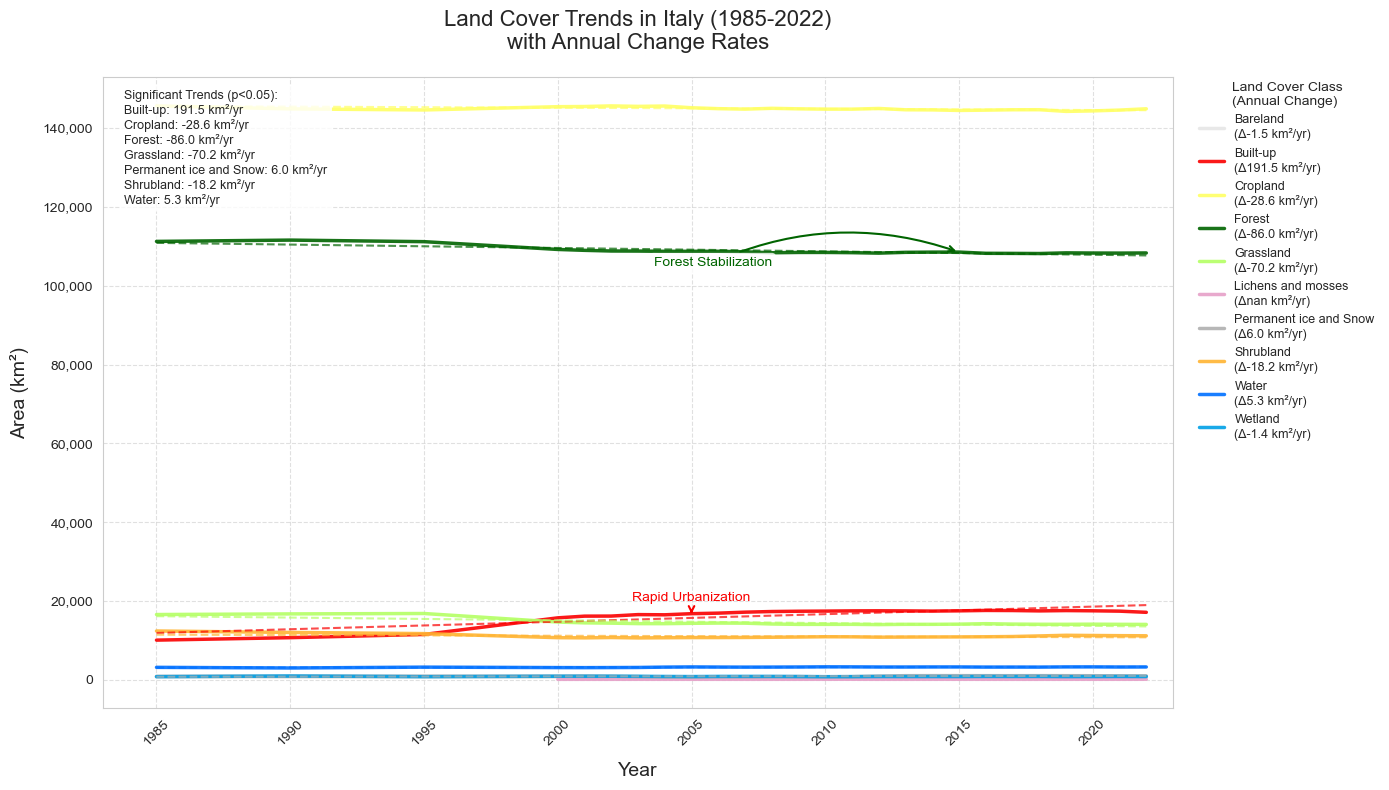


Land Cover Change Statistics (1985-2022):
                         slope   intercept  r_squared  p_value
Built-up               191.454 -368165.259      0.710    0.000
Permanent ice and Snow   5.957  -11050.183      0.239    0.011
Water                    5.274   -7384.108      0.470    0.000
Wetland                 -1.441    3733.828      0.127    0.074
Bareland                -1.538    3761.410      0.096    0.123
Shrubland              -18.167   47506.352      0.158    0.044
Cropland               -28.594  202354.248      0.438    0.000
Grassland              -70.227  155538.815      0.636    0.000
Forest                 -86.045  281671.582      0.725    0.000
Lichens and mosses         NaN         NaN        NaN      NaN


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import numpy as np
from scipy.stats import linregress

# Load and prepare data
def load_and_prepare_data(filepath):
    """Load and preprocess the land cover data"""
    df = pd.read_csv(filepath)
    df['Year'] = pd.to_datetime(df['Year'], format='%Y')
    df['Year_Num'] = df['Year'].dt.year
    trend_df = df.pivot(index='Year_Num', columns='Label', values='Area_km2')
    return df, trend_df

# Color palette (ESA CCI standard)
CCI_PALETTE = {
    'Cropland': '#ffff64',
    'Forest': '#006400',
    'Grassland': '#b4ff64',
    'Shrubland': '#ffb432',
    'Built-up': '#fa0000',
    'Water': '#0070ff',
    'Permanent ice and Snow': '#afafaf',
    'Wetland': '#00a0e6',
    'Bareland': '#e6e6e6',
    'Lichens and mosses': '#e6a0c8'
}

# Calculate trends
def calculate_trends(trend_df):
    """Calculate linear trends for all classes"""
    trends = {}
    for label in trend_df.columns:
        slope, intercept, r_value, p_value, _ = linregress(trend_df.index, trend_df[label])
        trends[label] = {
            'slope': slope,
            'intercept': intercept,
            'r_squared': r_value**2,
            'p_value': p_value
        }
    return pd.DataFrame(trends).T

# Plotting function
def plot_landcover_trends(trend_df, trends_df):
    """Create the land cover trends plot"""
    plt.figure(figsize=(14, 8))
    sns.set_style("whitegrid")
    plt.rcParams['font.family'] = 'Arial'
    
    # Plot each land cover class
    for label in trend_df.columns:
        plt.plot(trend_df.index, trend_df[label], 
                 label=f"{label}\n(Δ{trends_df.loc[label, 'slope']:.1f} km²/yr)",
                 color=CCI_PALETTE.get(label, '#333333'),
                 linewidth=2.5,
                 alpha=0.9)
    
    # Highlight significant trends (p<0.05)
    for label in trends_df[trends_df['p_value'] < 0.05].index:
        z = np.polyfit(trend_df.index, trend_df[label], 1)
        p = np.poly1d(z)
        plt.plot(trend_df.index, p(trend_df.index), 
                 color=CCI_PALETTE[label],
                 linestyle='--',
                 linewidth=1.5,
                 alpha=0.7)
    
    # Formatting
    plt.title('Land Cover Trends in Italy (1985-2022)\nwith Annual Change Rates', 
              fontsize=16, pad=20)
    plt.xlabel('Year', fontsize=14, labelpad=10)
    plt.ylabel('Area (km²)', fontsize=14, labelpad=10)
    
    plt.xticks(np.arange(1985, 2023, 5), rotation=45)
    plt.xlim(1983, 2023)
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Enhanced legend
    legend = plt.legend(fontsize=9, 
                        framealpha=1,
                        facecolor='white',
                        edgecolor='none',
                        bbox_to_anchor=(1.02, 1),
                        borderaxespad=0,
                        title='Land Cover Class\n(Annual Change)')
    legend.get_title().set_fontsize(10)
    
    # Annotations
    plt.annotate('Rapid Urbanization', 
                 xy=(2005, 16000), 
                 xytext=(2005, 20000),
                 arrowprops=dict(arrowstyle='->', color='#fa0000', lw=1.5),
                 fontsize=10,
                 color='#fa0000',
                 ha='center')

    plt.annotate('Forest Stabilization', 
                 xy=(2015, 108500),
                 xytext=(2008, 105000),
                 arrowprops=dict(arrowstyle='->', color='#006400', lw=1.5,
                                 connectionstyle="arc3,rad=-0.2"),
                 fontsize=10,
                 color='#006400',
                 ha='right',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.8))
    
    # Statistics box
    stats_text = ("Significant Trends (p<0.05):\n" +
                  "\n".join([f"{k}: {row['slope']:.1f} km²/yr" 
                             for k, row in trends_df[trends_df['p_value'] < 0.05].iterrows()]))
    
    plt.gca().text(0.02, 0.98, stats_text,
                   transform=plt.gca().transAxes,
                   fontsize=9,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    return plt

# Main execution
if __name__ == "__main__":
    # Load data
    df, trend_df = load_and_prepare_data(
        'glc_italy_30m_stats_output2/glc_30m_detailed_stats_20250731_121834.csv'
    )
    
    # Calculate trends
    trends_df = calculate_trends(trend_df)
    
    # Create plot
    plot = plot_landcover_trends(trend_df, trends_df)
    
    # Save output
    plot.savefig('Italy_LandCover_Trends_1985-2022_Enhanced.png', 
                 dpi=300, 
                 bbox_inches='tight',
                 facecolor='white')
    
    plot.show()
    
    # Print trend statistics
    print("\nLand Cover Change Statistics (1985-2022):")
    print(trends_df.sort_values('slope', ascending=False).to_string(float_format="%.3f"))


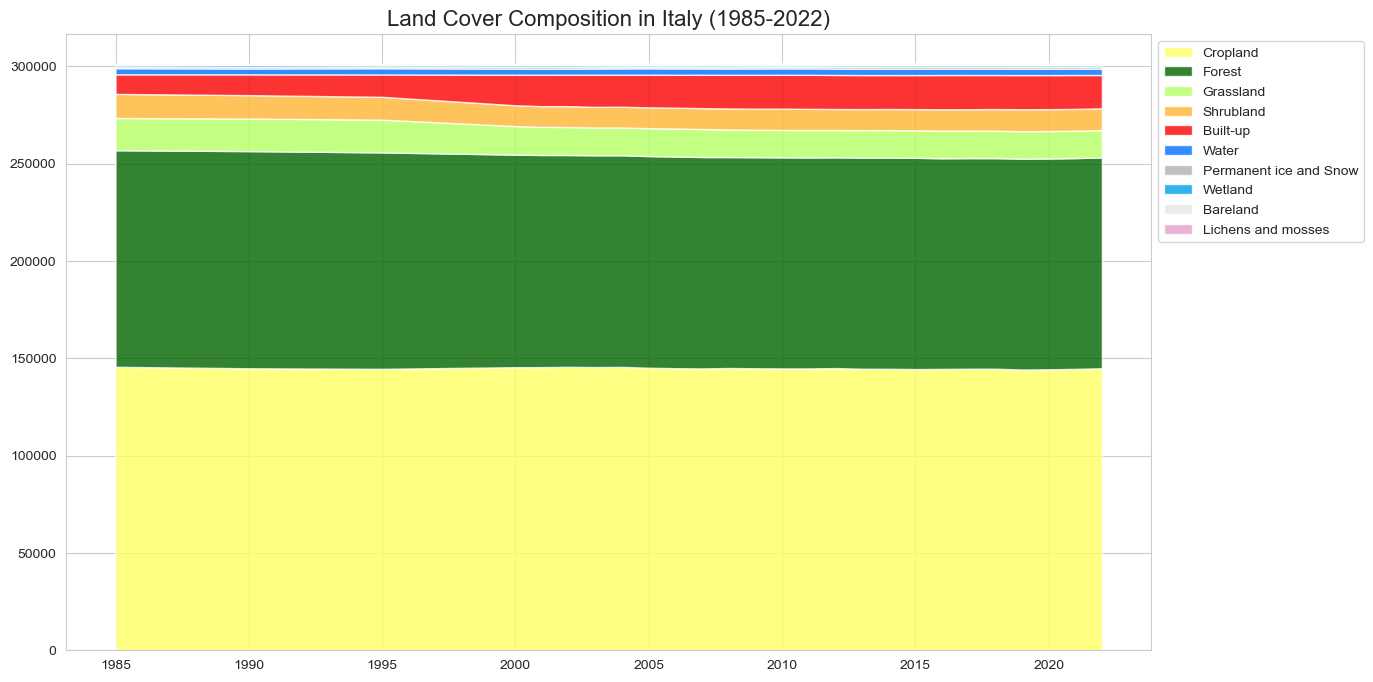

In [16]:
# Stacked area plot alternative
plt.figure(figsize=(14, 8))
plt.stackplot(trend_df.index, 
              [trend_df[col] for col in cci_palette.keys()],
              labels=cci_palette.keys(),
              colors=cci_palette.values(),
              alpha=0.8)
plt.title('Land Cover Composition in Italy (1985-2022)', fontsize=16)
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.savefig('Italy_LandCover_Composition.png', dpi=300, bbox_inches='tight')



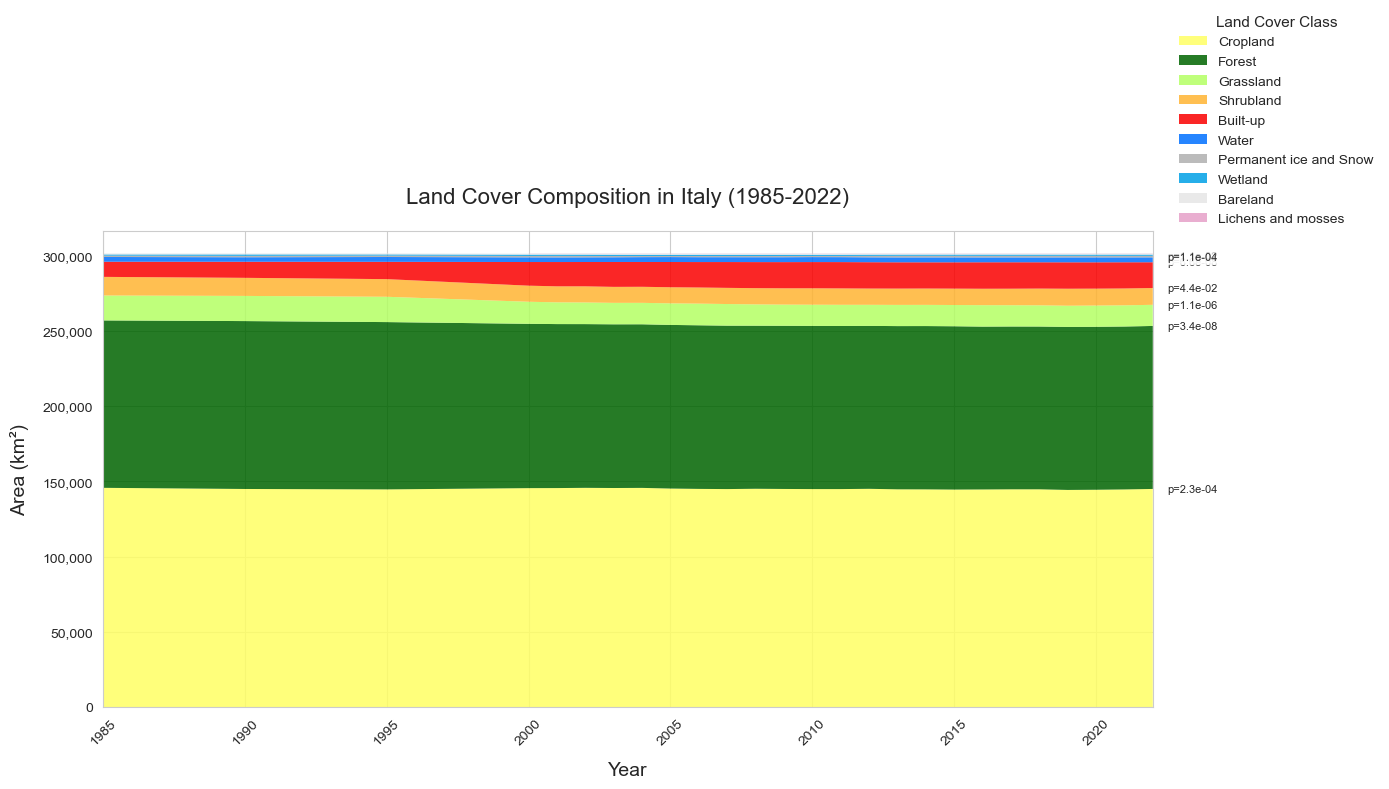

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import numpy as np
from scipy.stats import linregress

# Load and prepare data
df = pd.read_csv('glc_italy_30m_stats_output2/glc_30m_detailed_stats_20250731_121834.csv')
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df['Year_Num'] = df['Year'].dt.year
trend_df = df.pivot(index='Year_Num', columns='Label', values='Area_km2')

# ESA CCI color palette
cci_palette = {
    'Cropland': '#ffff64',
    'Forest': '#006400',
    'Grassland': '#b4ff64',
    'Shrubland': '#ffb432',
    'Built-up': '#fa0000',
    'Water': '#0070ff',
    'Permanent ice and Snow': '#afafaf',
    'Wetland': '#00a0e6',
    'Bareland': '#e6e6e6',
    'Lichens and mosses': '#e6a0c8'
}

# Create stacked area plot
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Arial'

# Option 1: Plot all classes (stacked)
plt.stackplot(trend_df.index,
             [trend_df[col] for col in cci_palette.keys()],
             labels=cci_palette.keys(),
             colors=cci_palette.values(),
             alpha=0.85,
             edgecolor='none')

# Option 2: Plot only focus classes (uncomment to use)
# focus_classes = ['Built-up', 'Forest', 'Grassland']
# plt.stackplot(trend_df.index,
#              [trend_df[col] for col in focus_classes],
#              labels=focus_classes,
#              colors=[cci_palette[col] for col in focus_classes],
#              alpha=0.85)

# Formatting
plt.title('Land Cover Composition in Italy (1985-2022)', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=14, labelpad=10)
plt.ylabel('Area (km²)', fontsize=14, labelpad=10)
plt.xticks(np.arange(1985, 2023, 5), rotation=45)
plt.xlim(1985, 2022)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Improved legend
legend = plt.legend(fontsize=10,
                   framealpha=1,
                   facecolor='white',
                   edgecolor='none',
                   bbox_to_anchor=(1.02, 1),
                   borderaxespad=0)
legend.set_title('Land Cover Class', prop={'size':11})

# Add statistical significance markers
for label in trend_df.columns:
    slope, _, r_value, p_value, _ = linregress(trend_df.index, trend_df[label])
    if p_value < 0.05:
        y_pos = trend_df[label].iloc[-1] + sum(trend_df[col].iloc[-1] 
                for col in cci_palette.keys() 
                if list(cci_palette.keys()).index(col) < list(cci_palette.keys()).index(label))
        
        plt.annotate(f"p={p_value:.1e}",
                    xy=(2022, y_pos),
                    xytext=(2022.5, y_pos),
                    fontsize=8,
                    va='center',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

# Adjust layout and save
plt.tight_layout()
plt.savefig('Italy_LandCover_Composition.png',
           dpi=300,
           bbox_inches='tight',
           facecolor='white')
plt.show()

Creating GLC_FCS30D 30m land cover visualizations...
Classes found in dataset: ['Shrubland' 'Grassland' 'Cropland' 'Wetland' 'Bareland' 'Built-up'
 'Water' 'Permanent ice and Snow' 'Forest' 'Lichens and mosses']


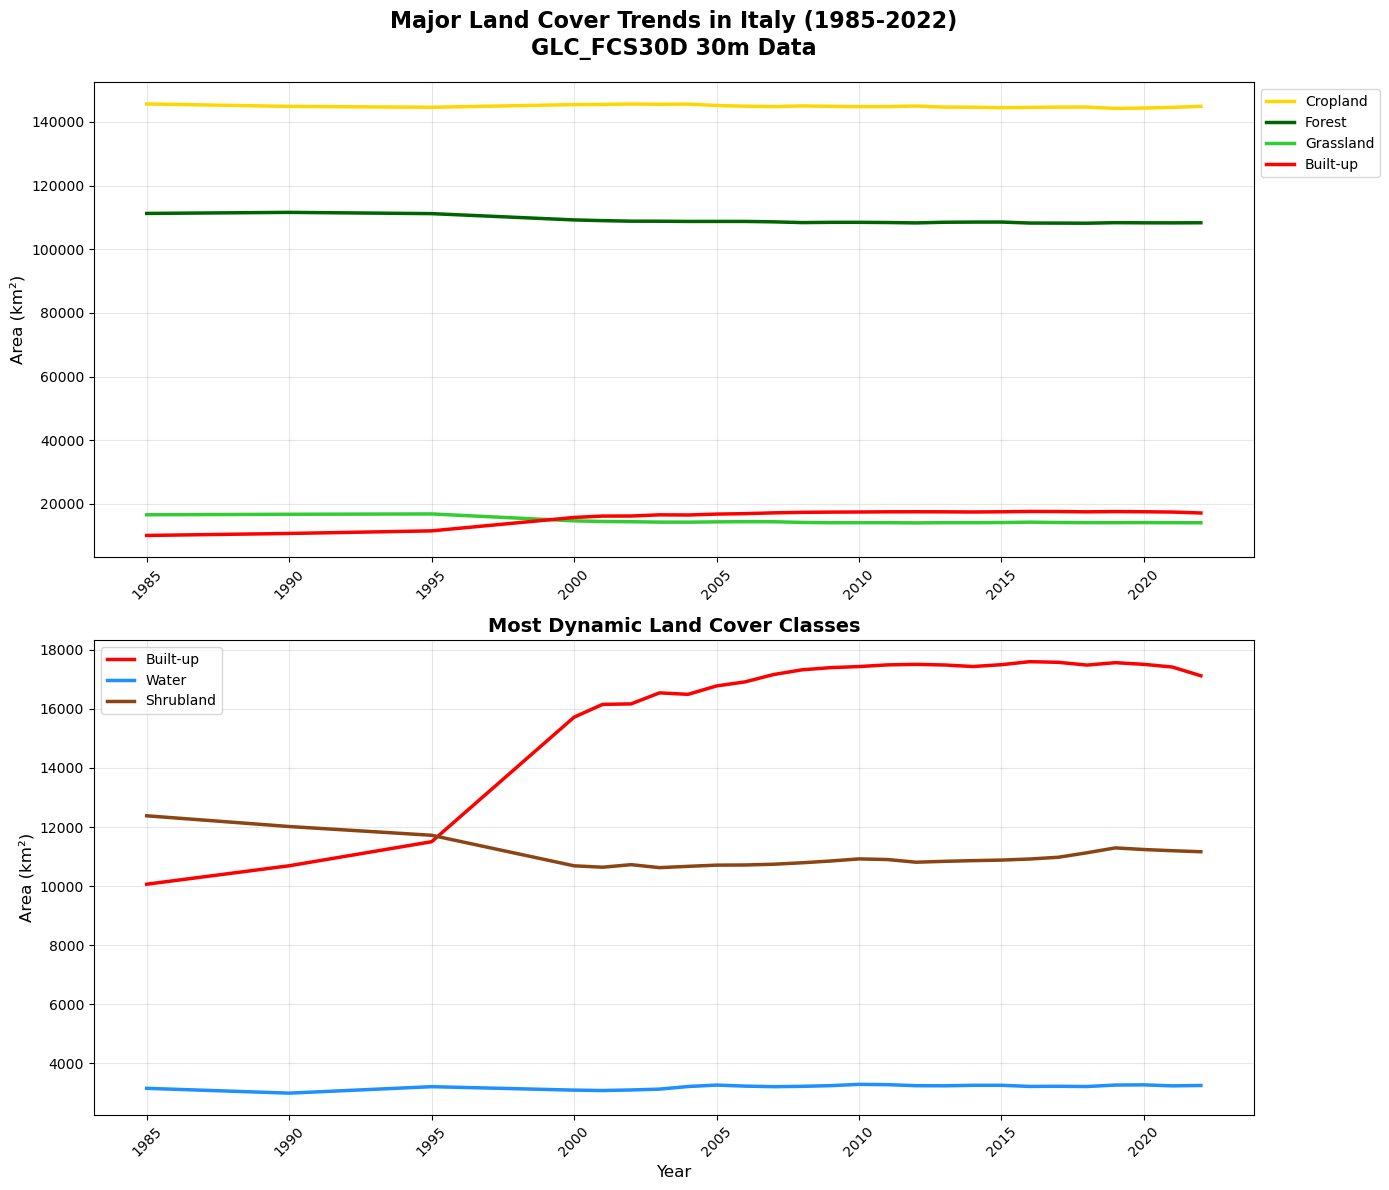

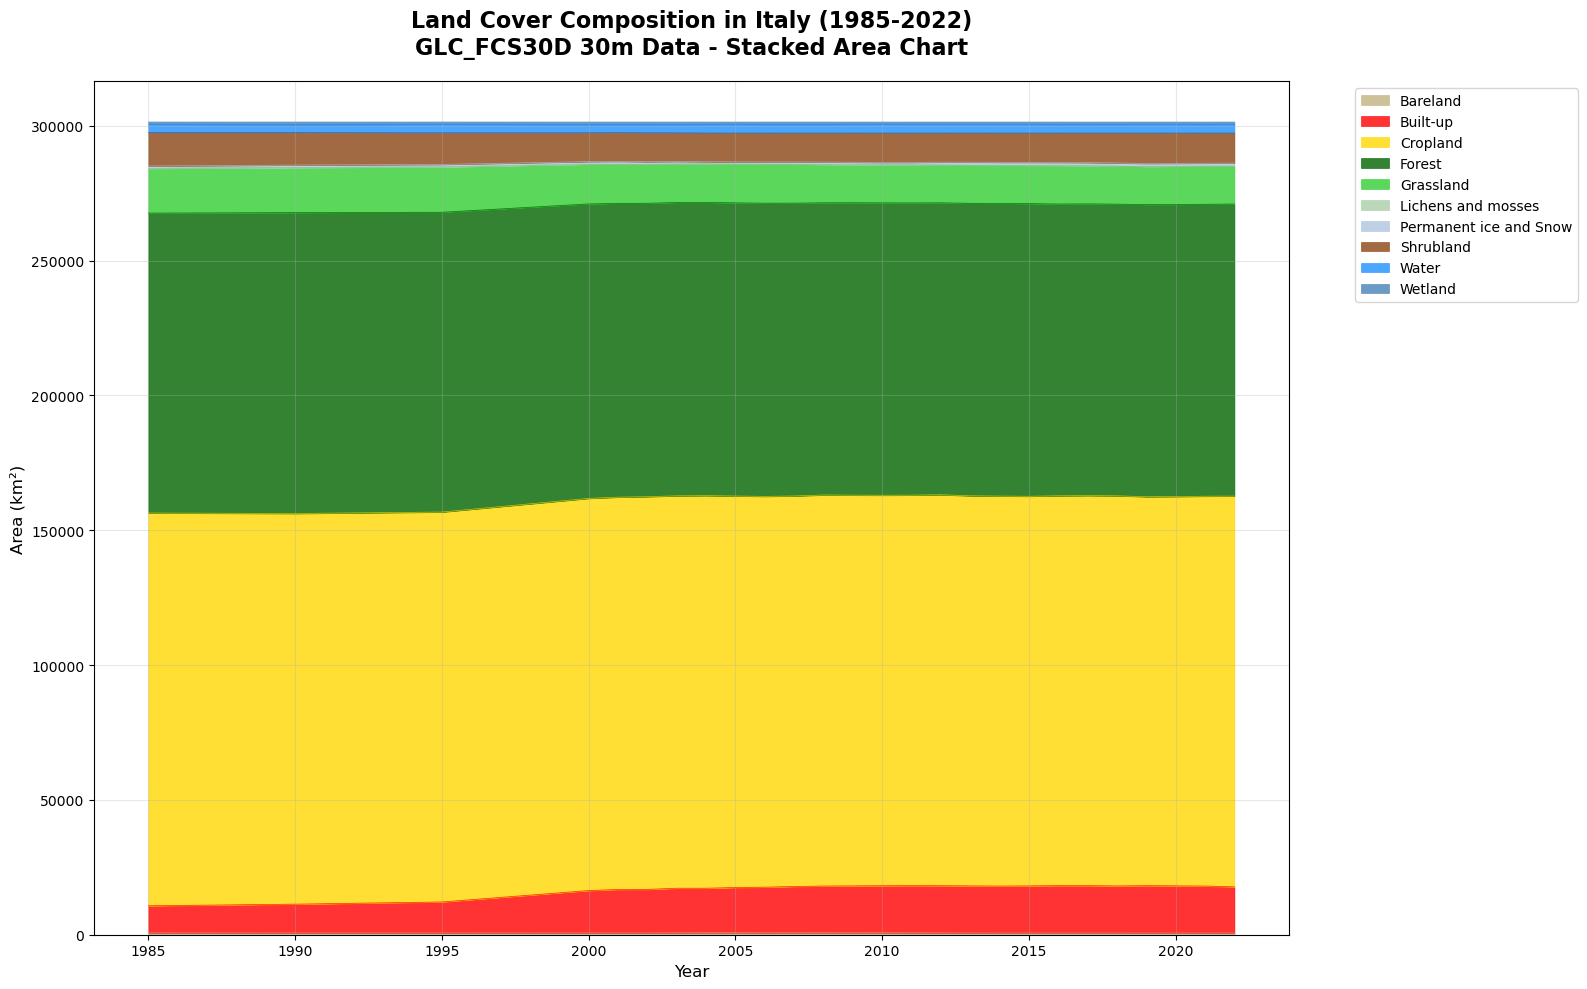

Available classes in dataset: ['Bareland', 'Built-up', 'Cropland', 'Forest', 'Grassland', 'Lichens and mosses', 'Permanent ice and Snow', 'Shrubland', 'Water', 'Wetland']


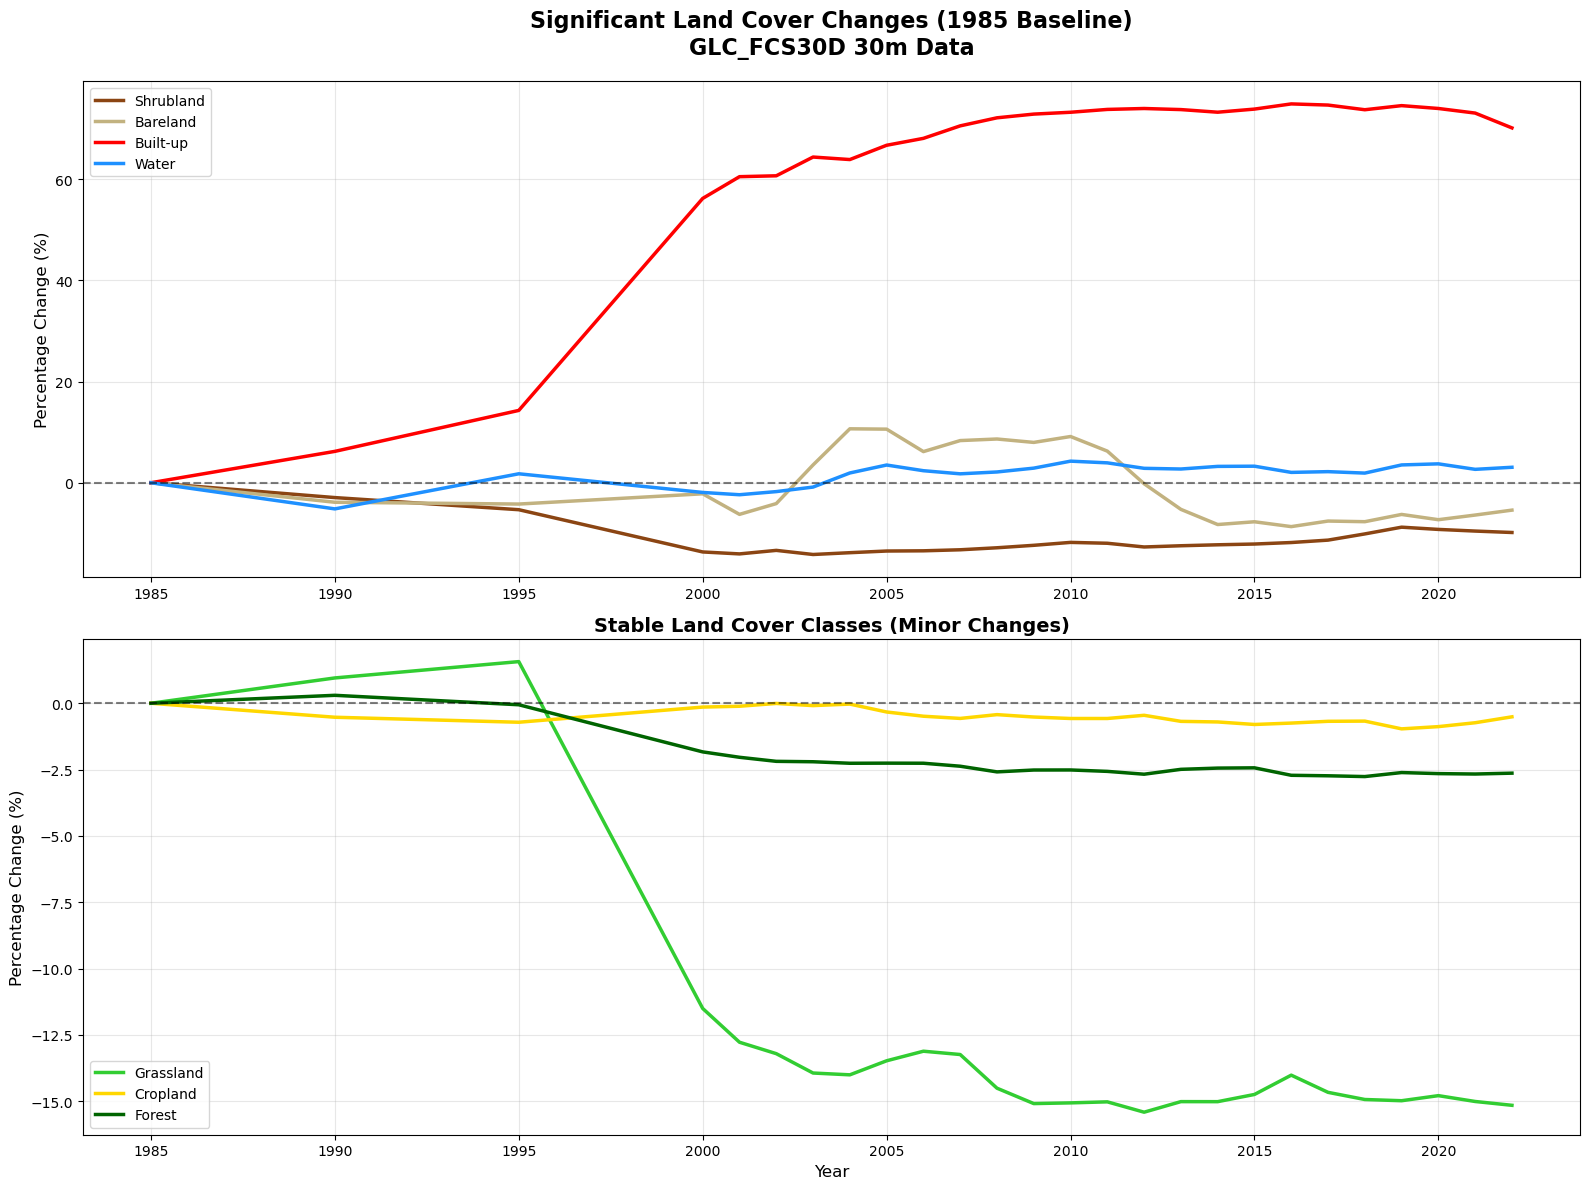

Summary of Actual Changes (1985-2022):
Shrubland: -9.83%
Grassland: -15.16%
Cropland: -0.51%
Wetland: +2.94%
Bareland: -5.41%
Built-up: +70.10%
Water: +3.06%
Permanent ice and Snow: +14.66%
Forest: -2.64%


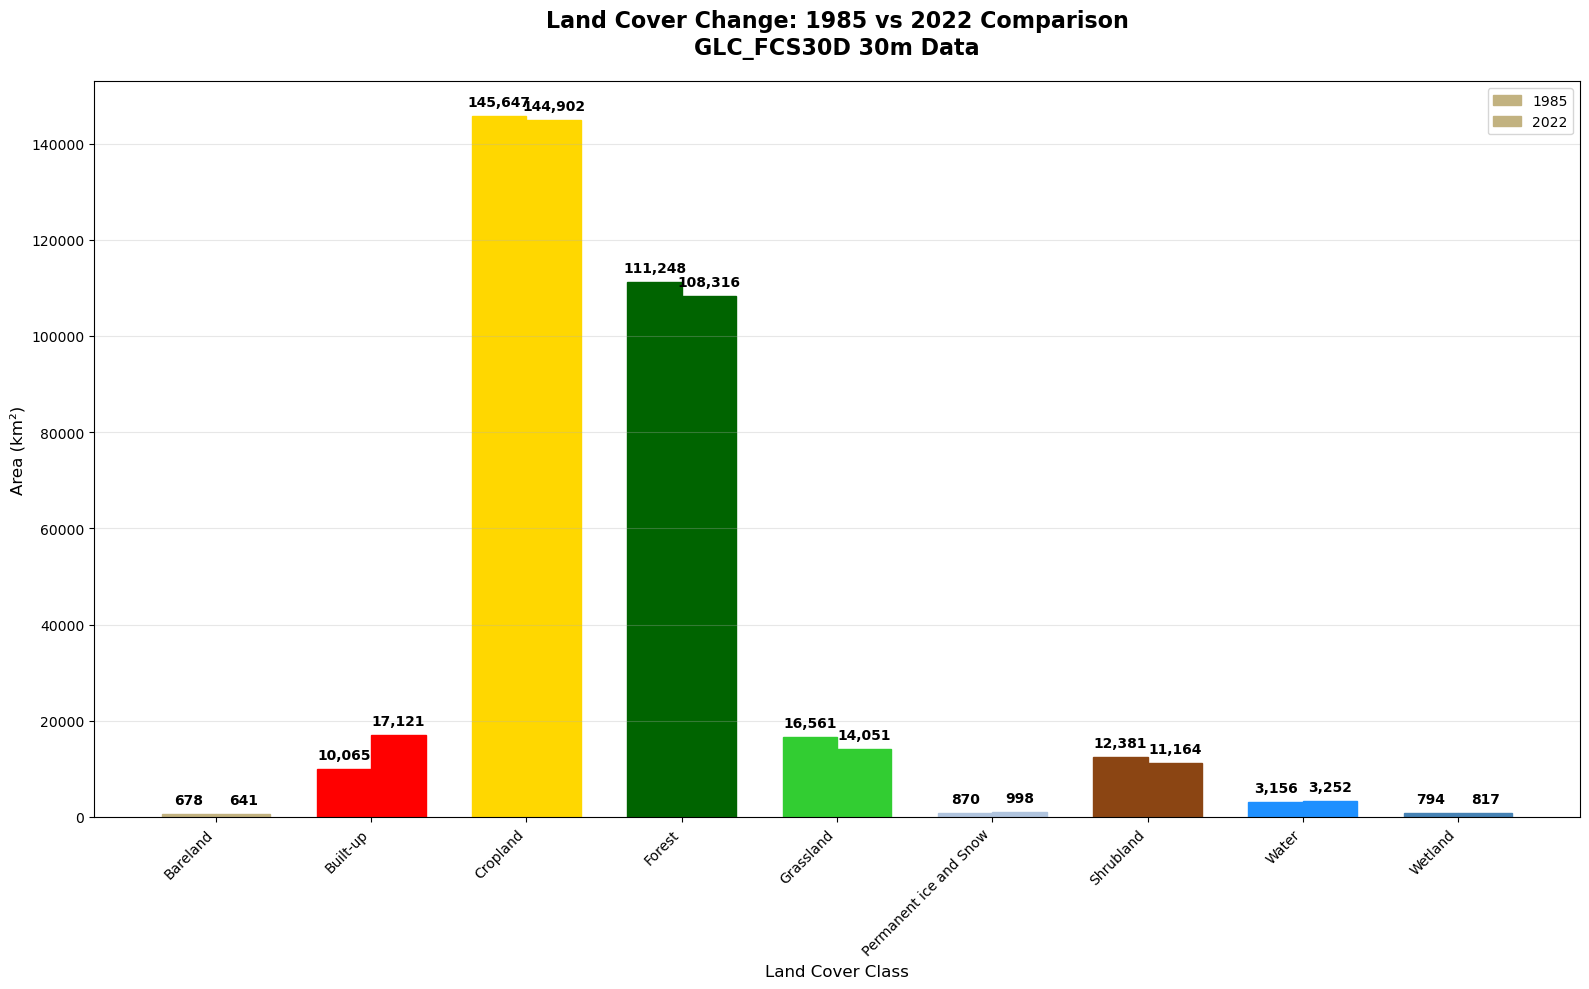

Classes compared in bar chart: ['Bareland', 'Built-up', 'Cropland', 'Forest', 'Grassland', 'Permanent ice and Snow', 'Shrubland', 'Water', 'Wetland']


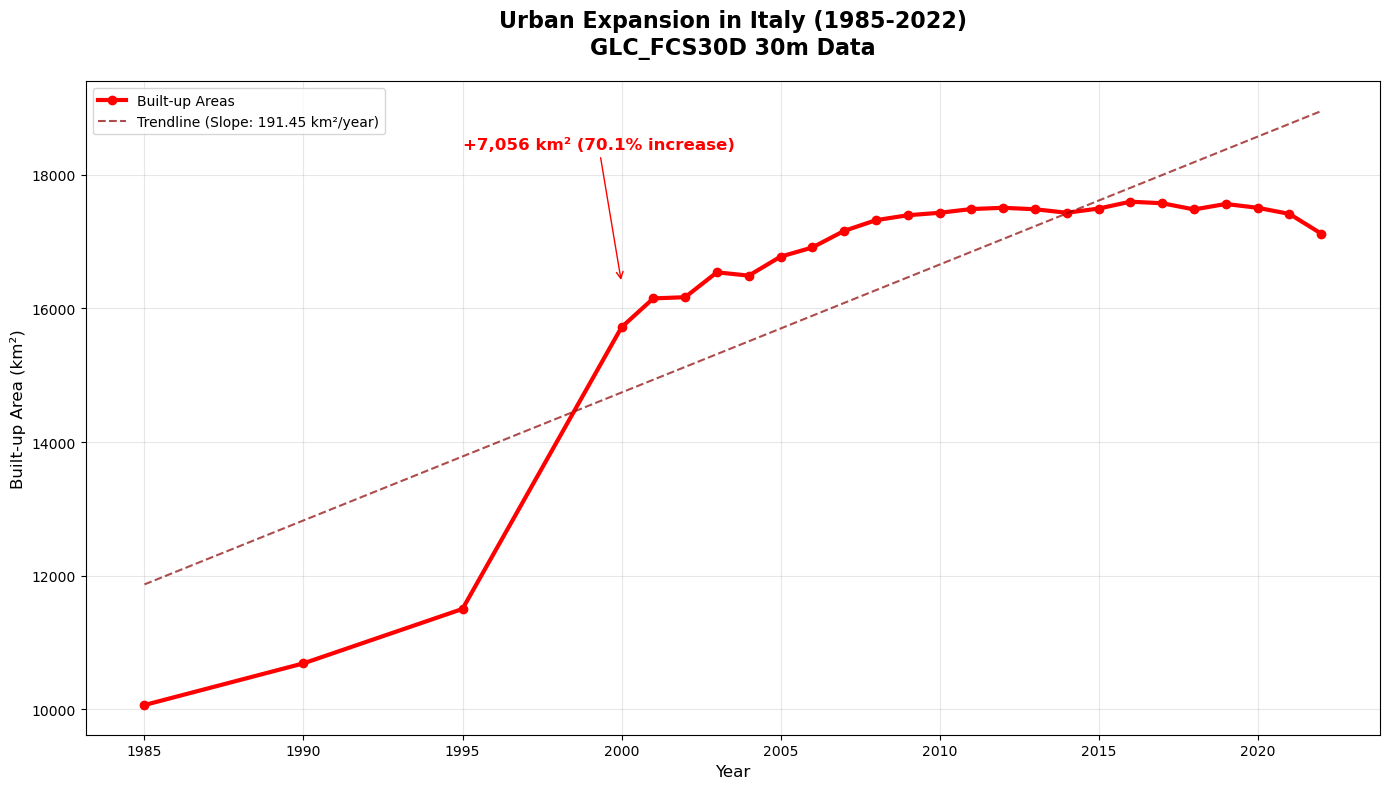

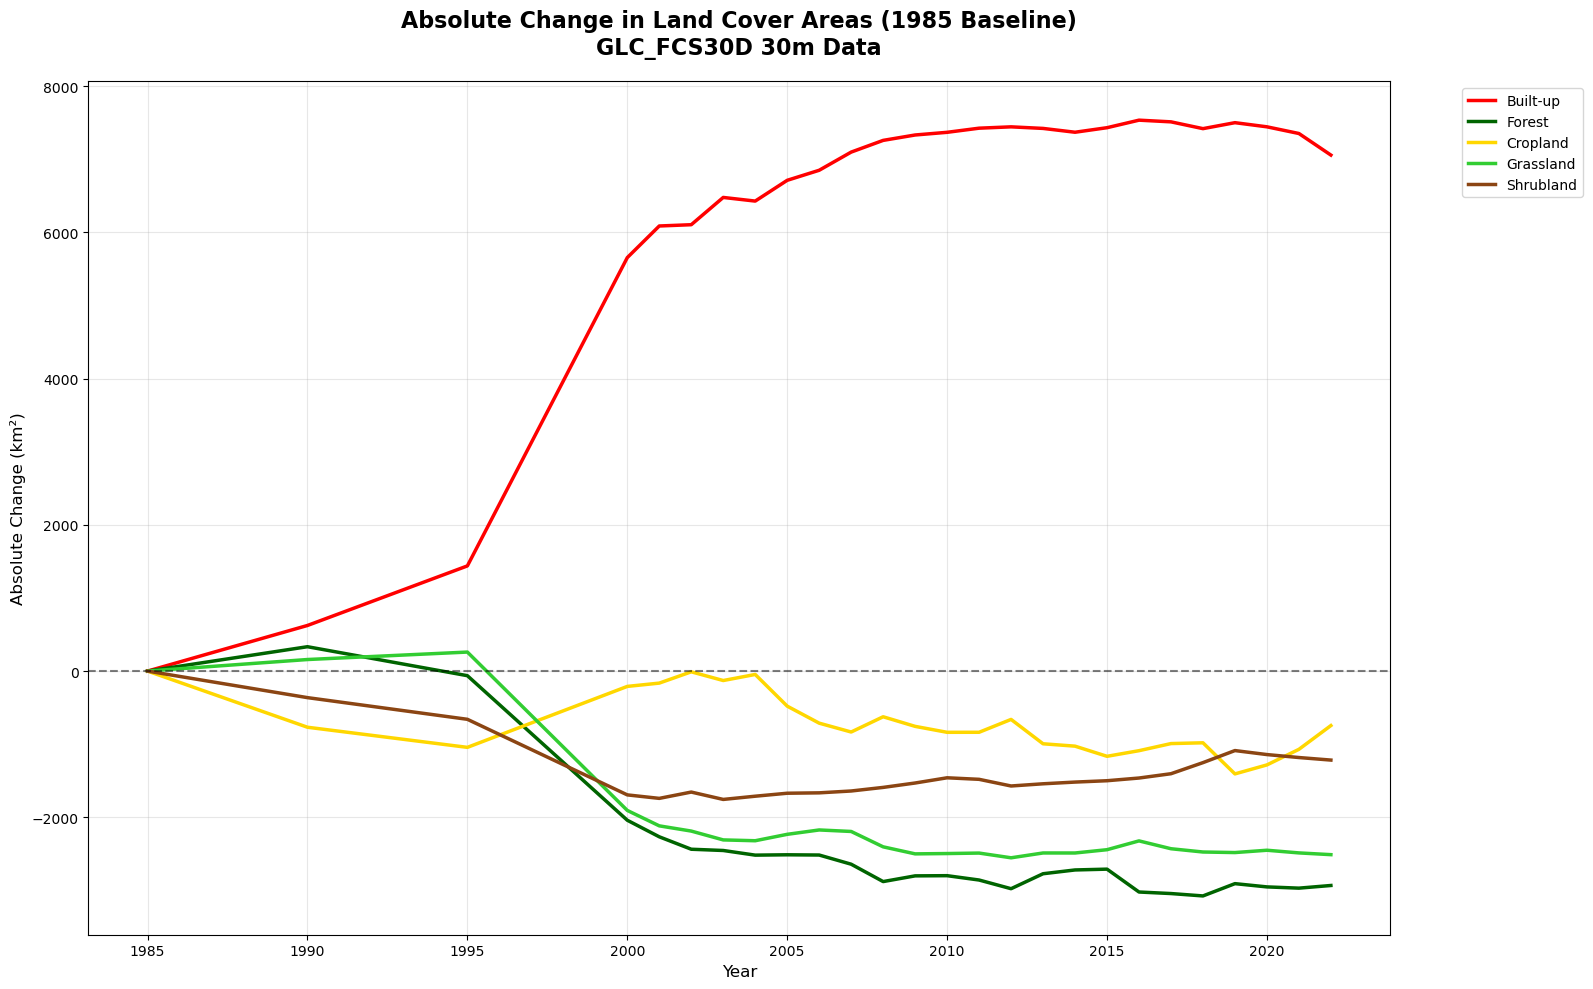

All visualizations completed! PNG files are saved in: /Users/ghulamabbaszafari/Downloads/CV/data/glc_landcover_trend


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ----------------------------
# 0. SET OUTPUT DIRECTORY
# ----------------------------
output_dir = '/Users/ghulamabbaszafari/Downloads/CV/data/glc_landcover_trend'
os.makedirs(output_dir, exist_ok=True)

# ----------------------------
# 1. SETUP AND DATA LOADING
# ----------------------------
file_path = "/Users/ghulamabbaszafari/Downloads/CV/data/glc_italy_30m_stats_output2/glc_30m_detailed_stats_20250731_121834.csv"
df = pd.read_csv(file_path)
df['Year'] = df['Year'].astype(int)

# Exact color scheme
color_map = {
    'Shrubland': '#8b4513',          
    'Grassland': '#32cd32',          
    'Cropland': '#ffd700',           
    'Wetland': '#4682b4',            
    'Lichens and mosses': '#a9cda9', 
    'Bareland': '#c2b280',           
    'Built-up': '#ff0000',           
    'Water': '#1e90ff',              
    'Permanent ice and Snow': '#b0c4de',  
    'Forest': '#006400',             
    'No data': '#ffffff'             
}

# ----------------------------
# 2. TIME SERIES TREND PLOTS
# ----------------------------
def create_trend_plots():
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
    
    # Major classes
    major_classes = ['Cropland', 'Forest', 'Grassland', 'Built-up']
    for class_name in major_classes:
        class_data = df[df['Label'] == class_name].groupby('Year')['Area_km2'].mean()
        ax1.plot(class_data.index, class_data.values, label=class_name, linewidth=2.5, color=color_map[class_name])
    
    ax1.set_title('Major Land Cover Trends in Italy (1985-2022)\nGLC_FCS30D 30m Data', fontsize=16, fontweight='bold', pad=20)
    ax1.set_ylabel('Area (km²)', fontsize=12)
    ax1.legend(loc='upper left', bbox_to_anchor=(1,1))
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # Changing classes
    changing_classes = ['Built-up', 'Water', 'Shrubland']
    for class_name in changing_classes:
        class_data = df[df['Label'] == class_name].groupby('Year')['Area_km2'].mean()
        ax2.plot(class_data.index, class_data.values, label=class_name, linewidth=2.5, color=color_map[class_name])
    
    ax2.set_title('Most Dynamic Land Cover Classes', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Year', fontsize=12)
    ax2.set_ylabel('Area (km²)', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'glc_30m_landcover_trends.png'), dpi=300, bbox_inches='tight')
    plt.show()

# ----------------------------
# 3. STACKED AREA CHART
# ----------------------------
def create_stacked_area_chart():
    pivot_df = df.pivot_table(index='Year', columns='Label', values='Area_km2', aggfunc='mean')
    available_classes = [col for col in pivot_df.columns if col in color_map]
    
    ax = pivot_df[available_classes].plot.area(
        figsize=(16, 10),
        color=[color_map[cls] for cls in available_classes],
        alpha=0.8,
        linewidth=0.5
    )
    
    plt.title('Land Cover Composition in Italy (1985-2022)\nGLC_FCS30D 30m Data - Stacked Area Chart', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Area (km²)', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'glc_30m_stacked_area_chart.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Available classes in dataset: {available_classes}")

# ----------------------------
# 4. CORRECTED PERCENTAGE CHANGE PLOT
# ----------------------------
def create_corrected_percentage_change_plot():
    baseline_1985 = df[df['Year']==1985].set_index('Label')['Area_km2']
    change_data = {}
    
    for class_name in df['Label'].unique():
        class_data = df[df['Label']==class_name].set_index('Year')['Area_km2']
        if class_name in baseline_1985.index and baseline_1985[class_name] > 0:
            change_data[class_name] = ((class_data - baseline_1985[class_name])/baseline_1985[class_name])*100
    
    change_df = pd.DataFrame(change_data)
    
    meaningful_classes = []
    for class_name in change_df.columns:
        max_change = change_df[class_name].abs().max()
        if max_change > 2 or class_name in ['Cropland', 'Forest', 'Built-up', 'Grassland']:
            meaningful_classes.append(class_name)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16,12))
    
    # Major changes
    for class_name in meaningful_classes:
        if class_name in ['Built-up','Water','Shrubland','Bareland']:
            ax1.plot(change_df.index, change_df[class_name], label=class_name, linewidth=2.5, color=color_map[class_name])
    ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax1.set_title('Significant Land Cover Changes (1985 Baseline)\nGLC_FCS30D 30m Data', fontsize=16, fontweight='bold', pad=20)
    ax1.set_ylabel('Percentage Change (%)', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Stable classes
    for class_name in meaningful_classes:
        if class_name in ['Cropland','Forest','Grassland']:
            ax2.plot(change_df.index, change_df[class_name], label=class_name, linewidth=2.5, color=color_map[class_name])
    ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax2.set_title('Stable Land Cover Classes (Minor Changes)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Year', fontsize=12)
    ax2.set_ylabel('Percentage Change (%)', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'glc_30m_corrected_percentage_change.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Summary of Actual Changes (1985-2022):")
    for class_name in meaningful_classes:
        change_2022 = change_df.loc[2022, class_name] if 2022 in change_df.index else change_df.iloc[-1][class_name]
        print(f"{class_name}: {change_2022:+.2f}%")

# ----------------------------
# 5. START/END COMPARISON BAR CHART WITH VALUES
# ----------------------------
def create_comparison_barchart_all_classes():
    data_1985 = df[df['Year']==1985].set_index('Label')['Area_km2']
    data_2022 = df[df['Year']==2022].set_index('Label')['Area_km2']
    common_classes = sorted(list(set(data_1985.index) & set(data_2022.index)))
    
    fig, ax = plt.subplots(figsize=(16,10))
    x = np.arange(len(common_classes))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, [data_1985[cls] for cls in common_classes], width, label='1985')
    bars2 = ax.bar(x + width/2, [data_2022[cls] for cls in common_classes], width, label='2022')
    
    for i, cls in enumerate(common_classes):
        bars1[i].set_color(color_map[cls])
        bars2[i].set_color(color_map[cls])
    
    # Add values on top
    for bar in bars1 + bars2:
        height = bar.get_height()
        ax.annotate(f'{height:,.0f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0,5),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color='black')
    
    ax.set_xlabel('Land Cover Class', fontsize=12)
    ax.set_ylabel('Area (km²)', fontsize=12)
    ax.set_title('Land Cover Change: 1985 vs 2022 Comparison\nGLC_FCS30D 30m Data', fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(common_classes, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'glc_30m_1985_vs_2022_comparison.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Classes compared in bar chart: {common_classes}")

# ----------------------------
# 6. URBANIZATION FOCUS PLOT
# ----------------------------
def create_urbanization_focus_plot():
    builtup_data = df[df['Label']=='Built-up'].groupby('Year')['Area_km2'].mean()
    plt.figure(figsize=(14,8))
    plt.plot(builtup_data.index, builtup_data.values, label='Built-up Areas', linewidth=3, color='#ff0000', marker='o')
    
    z = np.polyfit(builtup_data.index, builtup_data.values, 1)
    p = np.poly1d(z)
    plt.plot(builtup_data.index, p(builtup_data.index), linestyle='--', color='darkred', alpha=0.7, label=f'Trendline (Slope: {z[0]:.2f} km²/year)')
    
    plt.title('Urban Expansion in Italy (1985-2022)\nGLC_FCS30D 30m Data', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Built-up Area (km²)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    total_increase = builtup_data[2022] - builtup_data[1985]
    percent_increase = (total_increase / builtup_data[1985]) * 100
    plt.annotate(f'+{total_increase:,.0f} km² ({percent_increase:.1f}% increase)',
                 xy=(2000, builtup_data.mean()),
                 xytext=(1995, builtup_data.mean()+2000),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=12, fontweight='bold', color='red')
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'glc_30m_urbanization_trend.png'), dpi=300, bbox_inches='tight')
    plt.show()

# ----------------------------
# 7. ABSOLUTE CHANGE PLOT
# ----------------------------
def create_absolute_change_plot():
    baseline_1985 = df[df['Year']==1985].set_index('Label')['Area_km2']
    change_data = {}
    
    for class_name in df['Label'].unique():
        class_data = df[df['Label']==class_name].set_index('Year')['Area_km2']
        if class_name in baseline_1985.index:
            change_data[class_name] = class_data - baseline_1985[class_name]
    
    change_df = pd.DataFrame(change_data)
    
    significant_classes = ['Built-up','Forest','Cropland','Grassland','Shrubland']
    plt.figure(figsize=(16,10))
    for class_name in significant_classes:
        if class_name in change_df.columns:
            plt.plot(change_df.index, change_df[class_name], label=class_name, linewidth=2.5, color=color_map[class_name])
    
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.title('Absolute Change in Land Cover Areas (1985 Baseline)\nGLC_FCS30D 30m Data', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Absolute Change (km²)', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'glc_30m_absolute_change.png'), dpi=300, bbox_inches='tight')
    plt.show()

# ----------------------------
# 8. RUN ALL VISUALIZATIONS
# ----------------------------
if __name__ == "__main__":
    print("Creating GLC_FCS30D 30m land cover visualizations...")
    
    available_classes = df['Label'].unique()
    print(f"Classes found in dataset: {available_classes}")
    
    plt.style.use('default')
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['font.size'] = 10
    plt.rcParams['figure.facecolor'] = 'white'
    
    create_trend_plots()
    create_stacked_area_chart()
    create_corrected_percentage_change_plot()
    create_comparison_barchart_all_classes()
    create_urbanization_focus_plot()
    create_absolute_change_plot()
    
    print("All visualizations completed! PNG files are saved in:", output_dir)





Data period covered:
Start Year: 1985
End Year:   2022

Index details:
RangeIndex(start=0, stop=257, step=1)

Missing years in dataset: [1986, 1987, 1988, 1989, 1991, 1992, 1993, 1994, 1996, 1997, 1998, 1999]
⚠️ Note: Expected (every 5 years until 2000, then annual).
Creating GLC_FCS30D land cover visualizations...


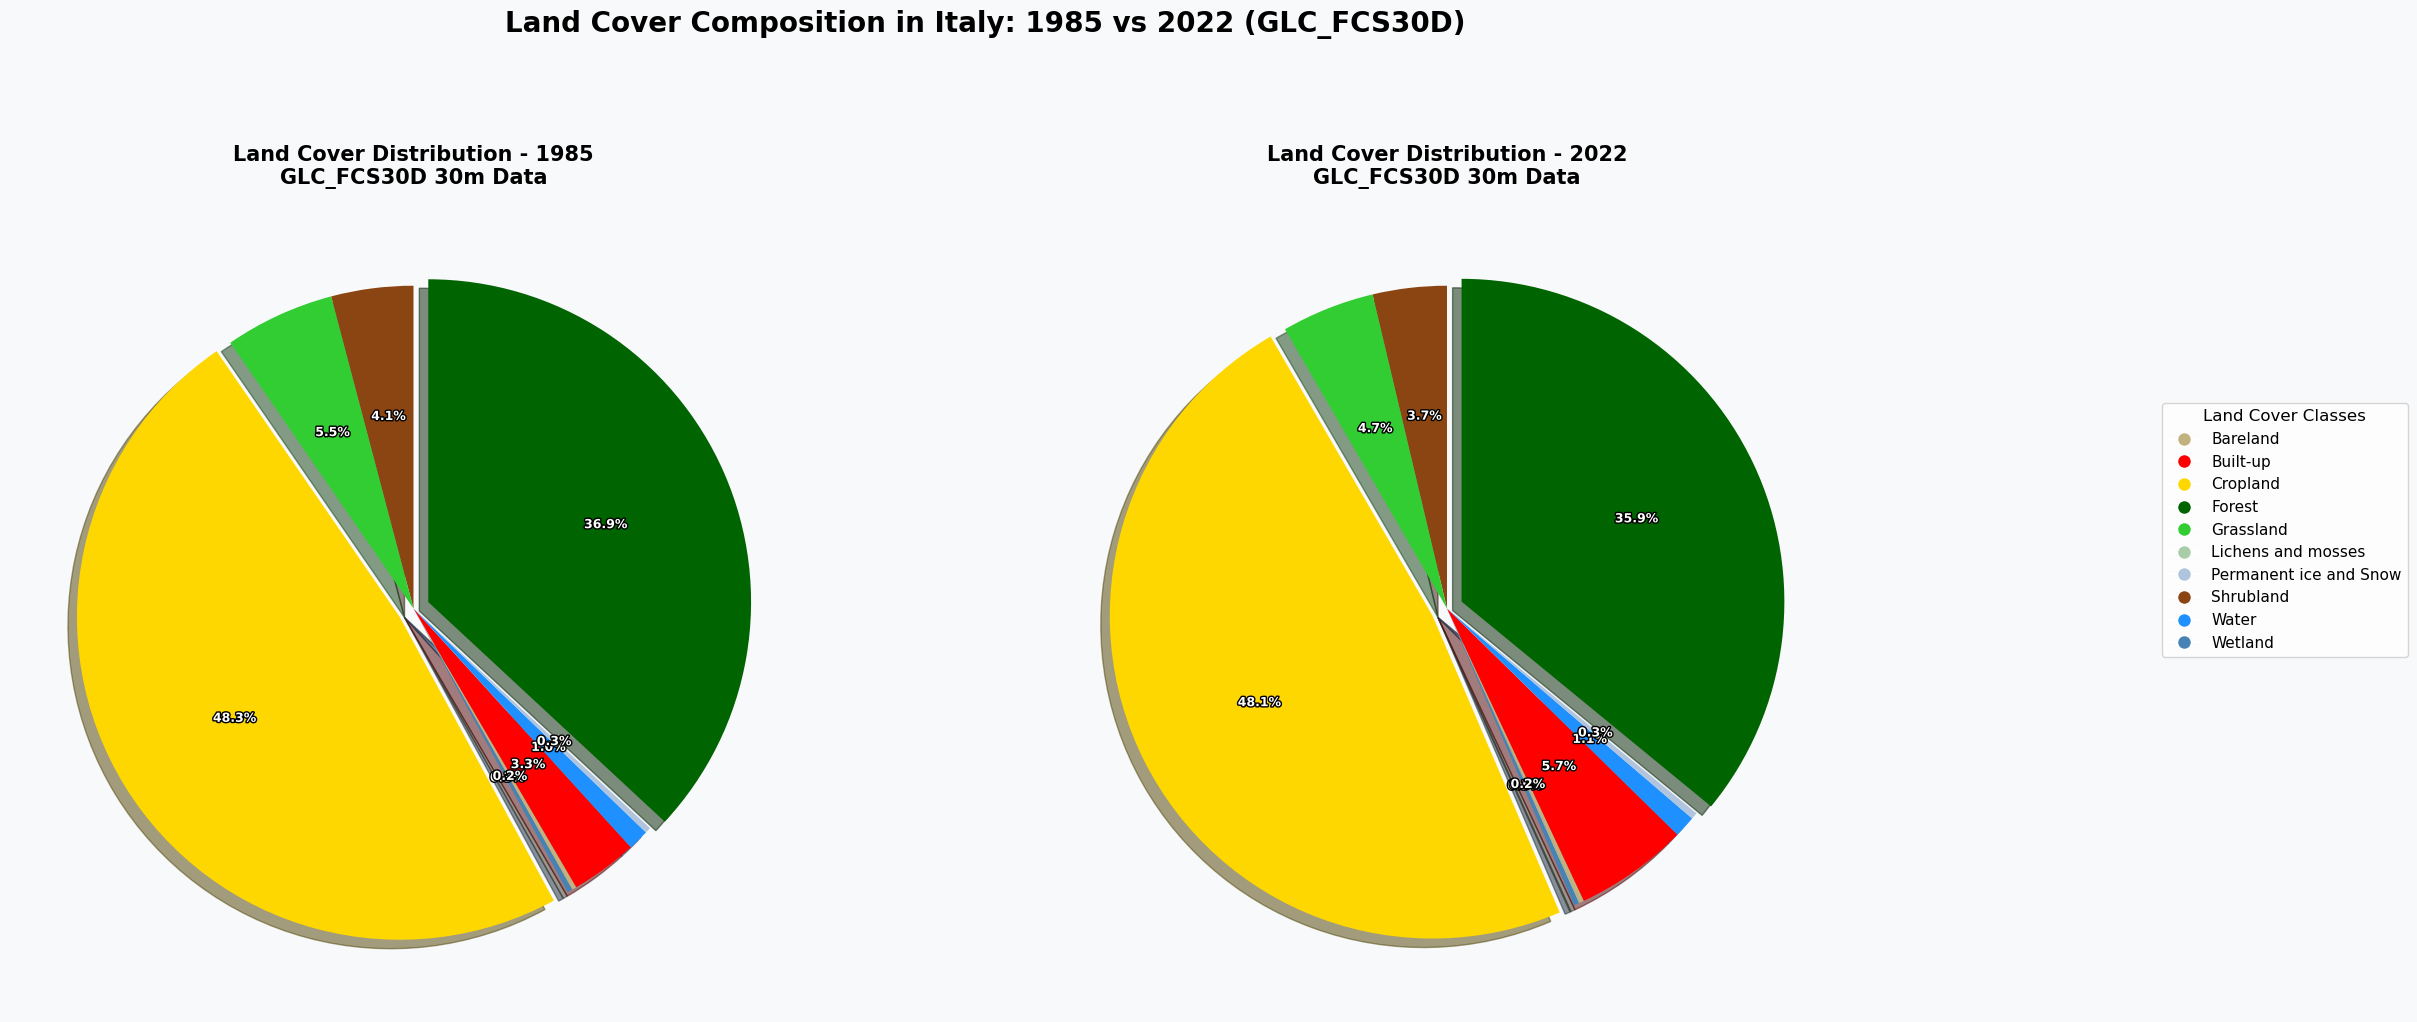

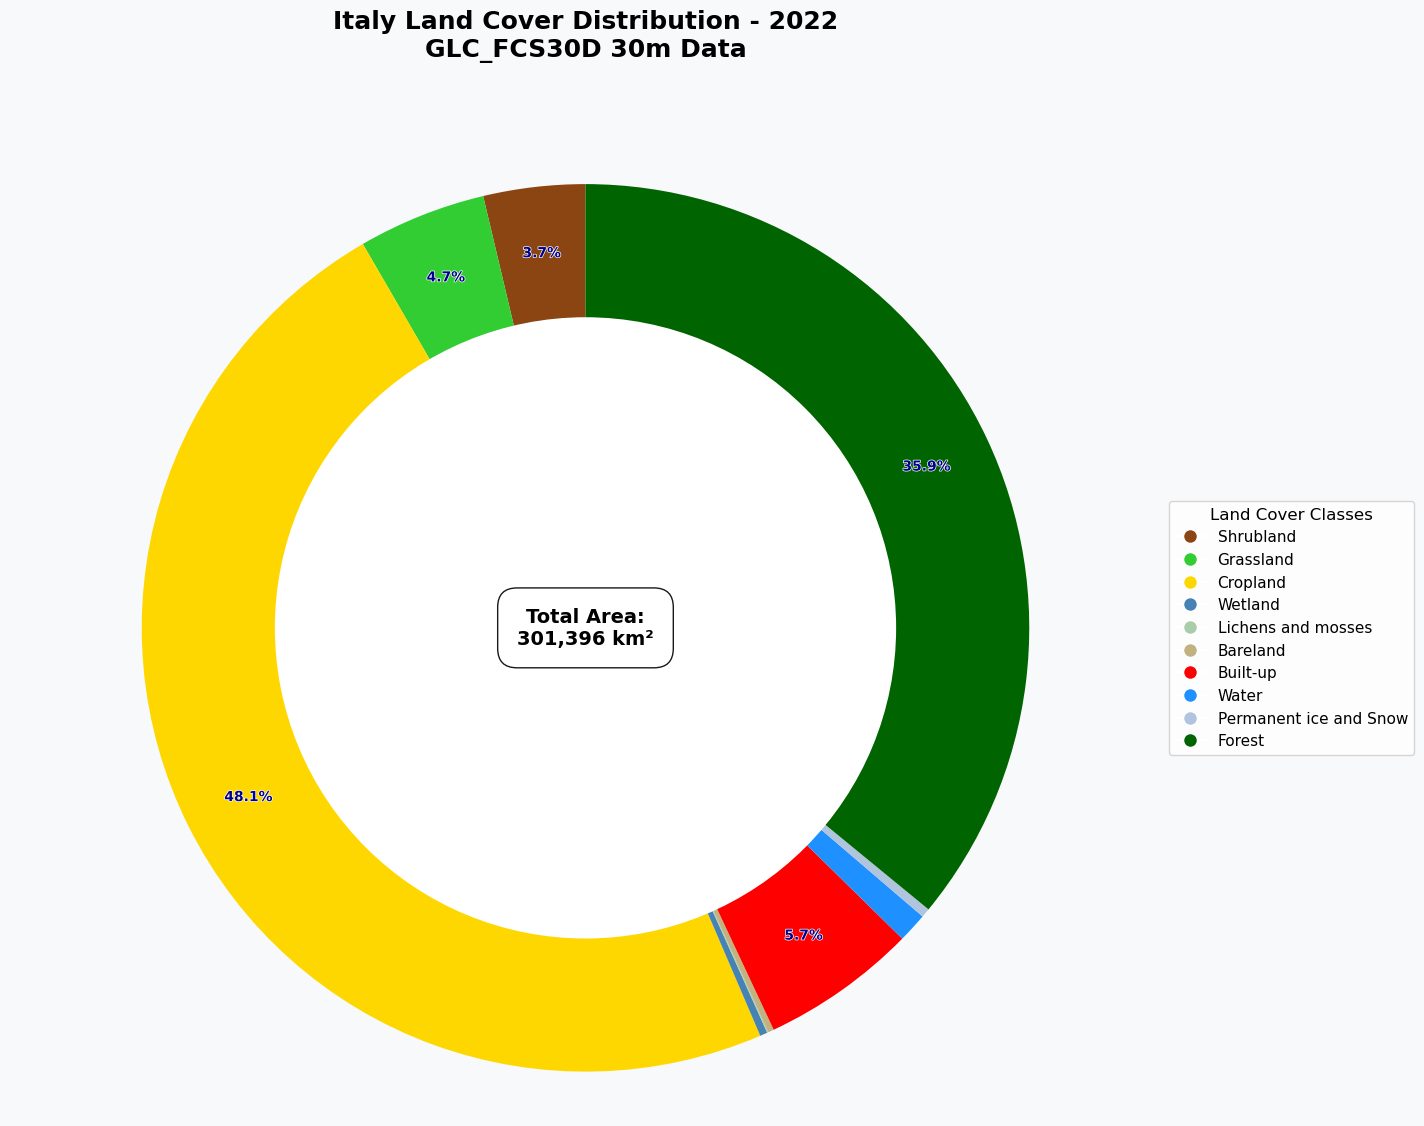

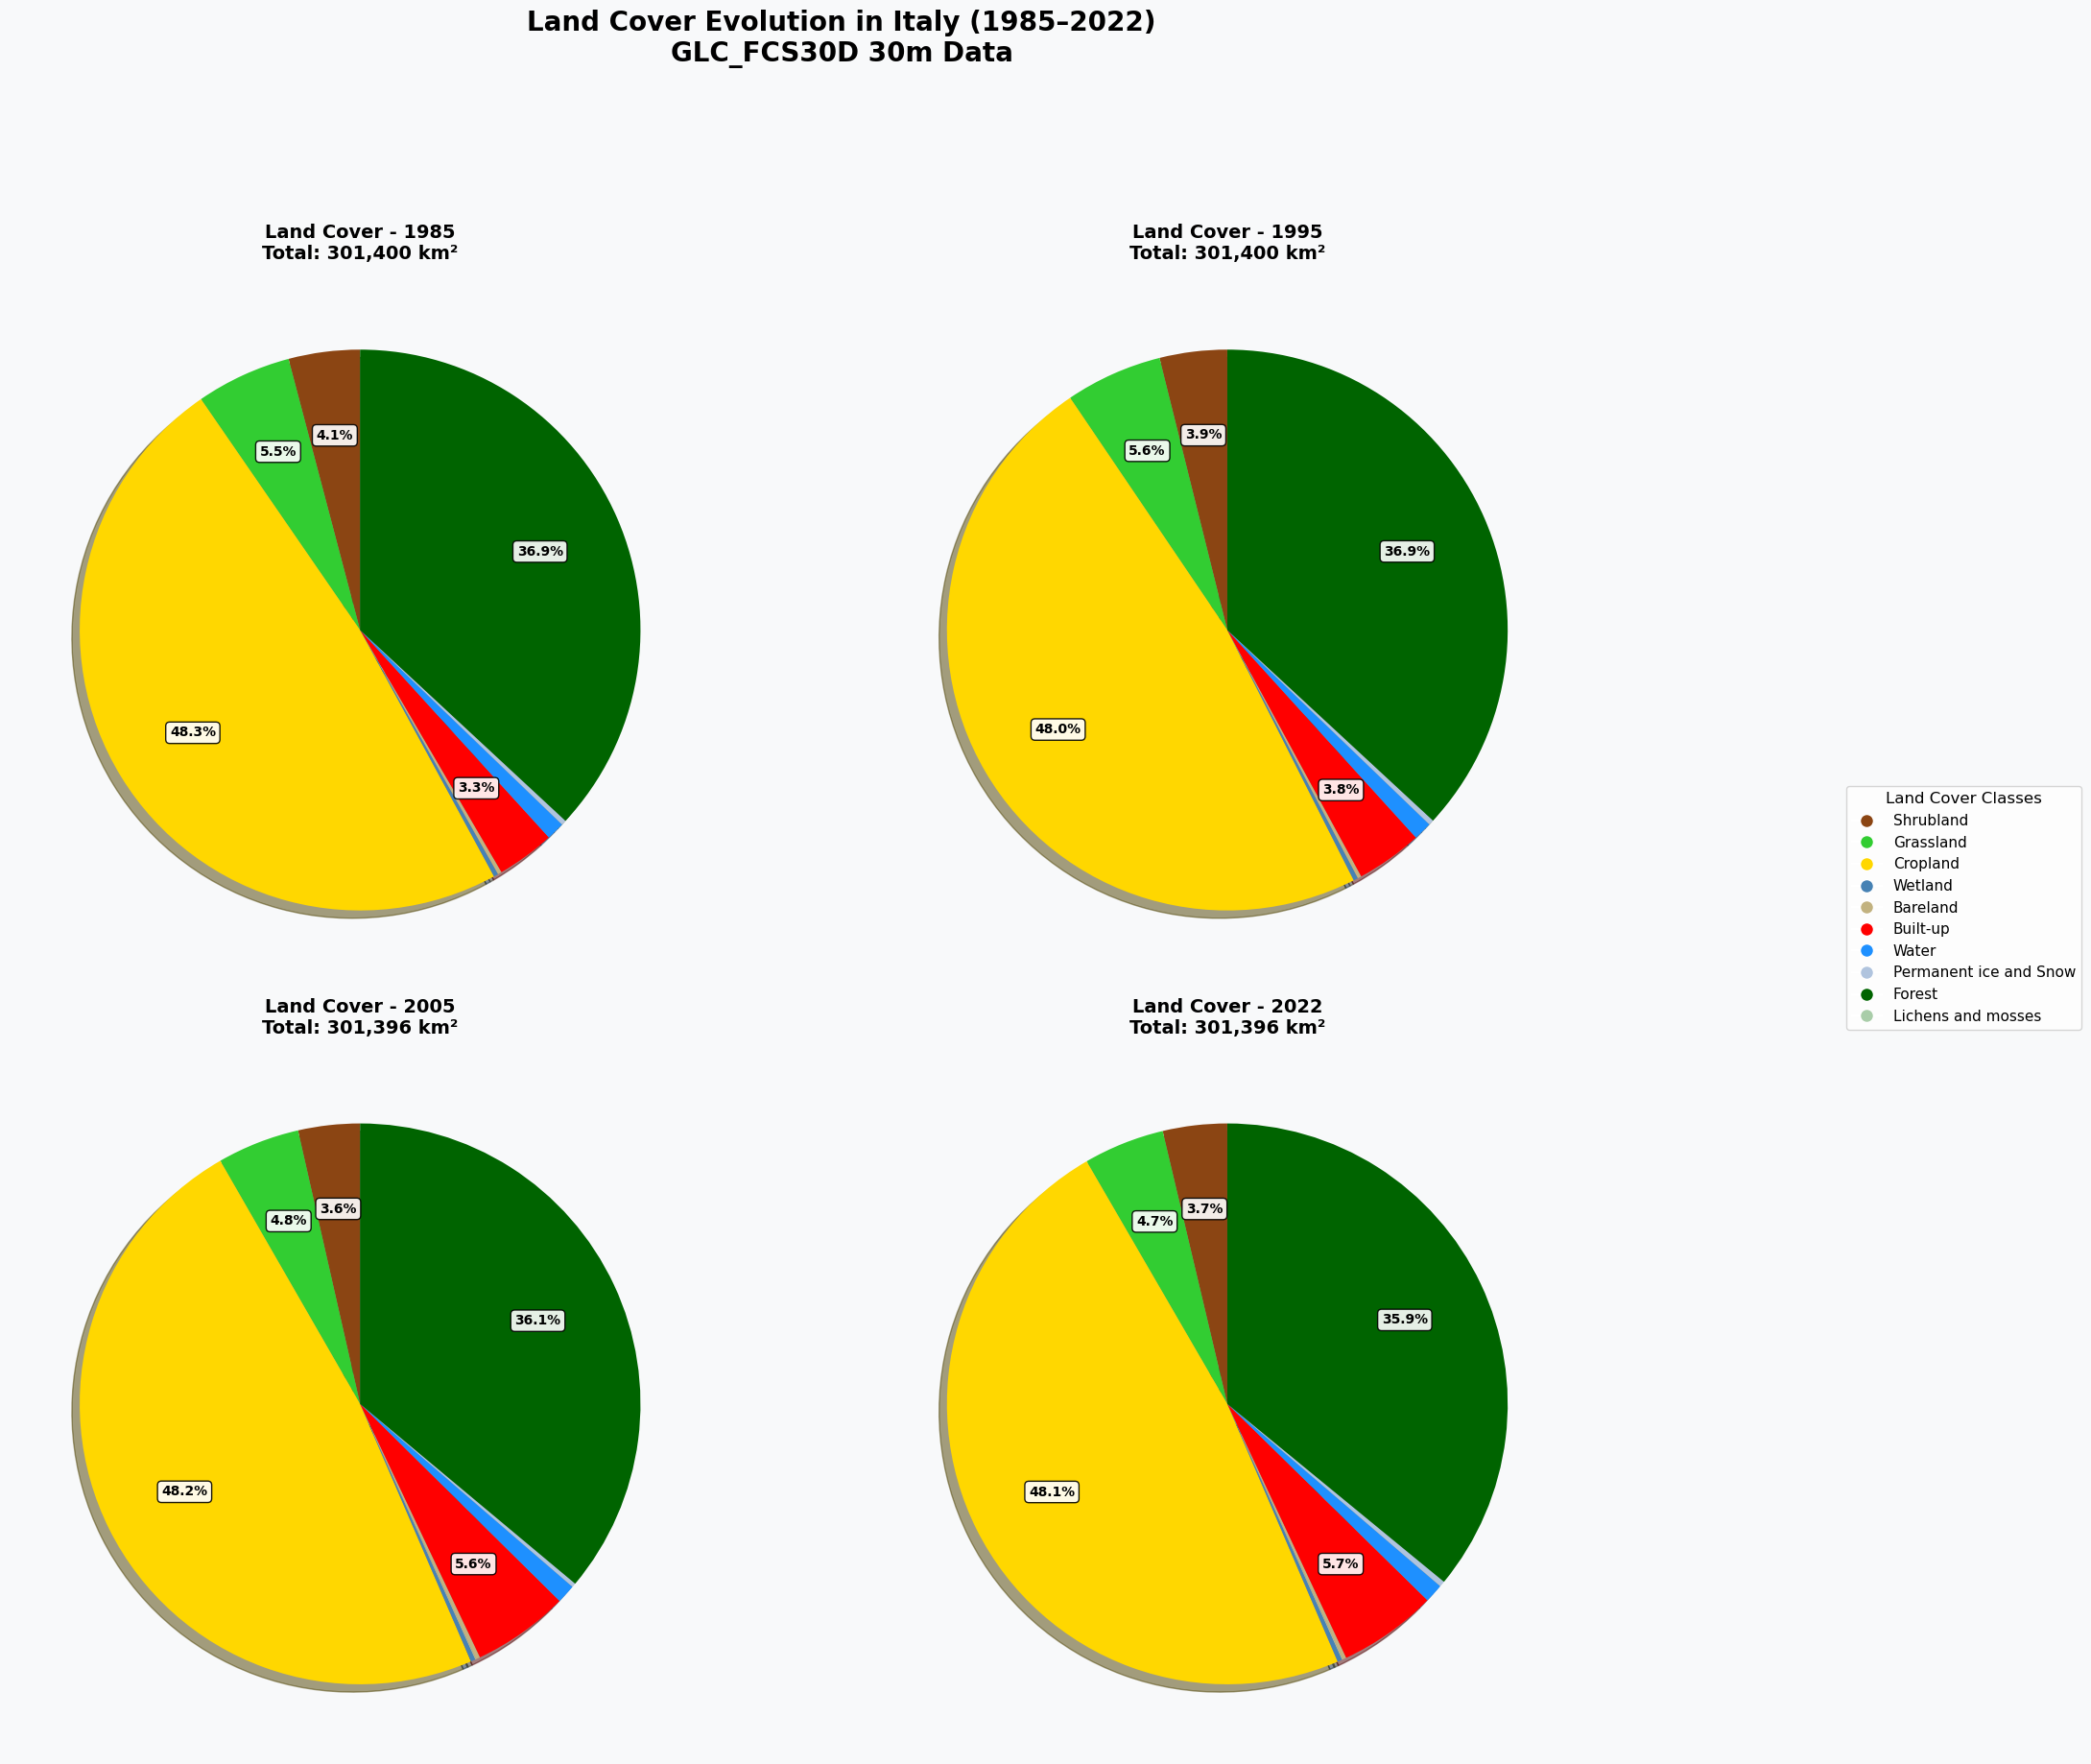

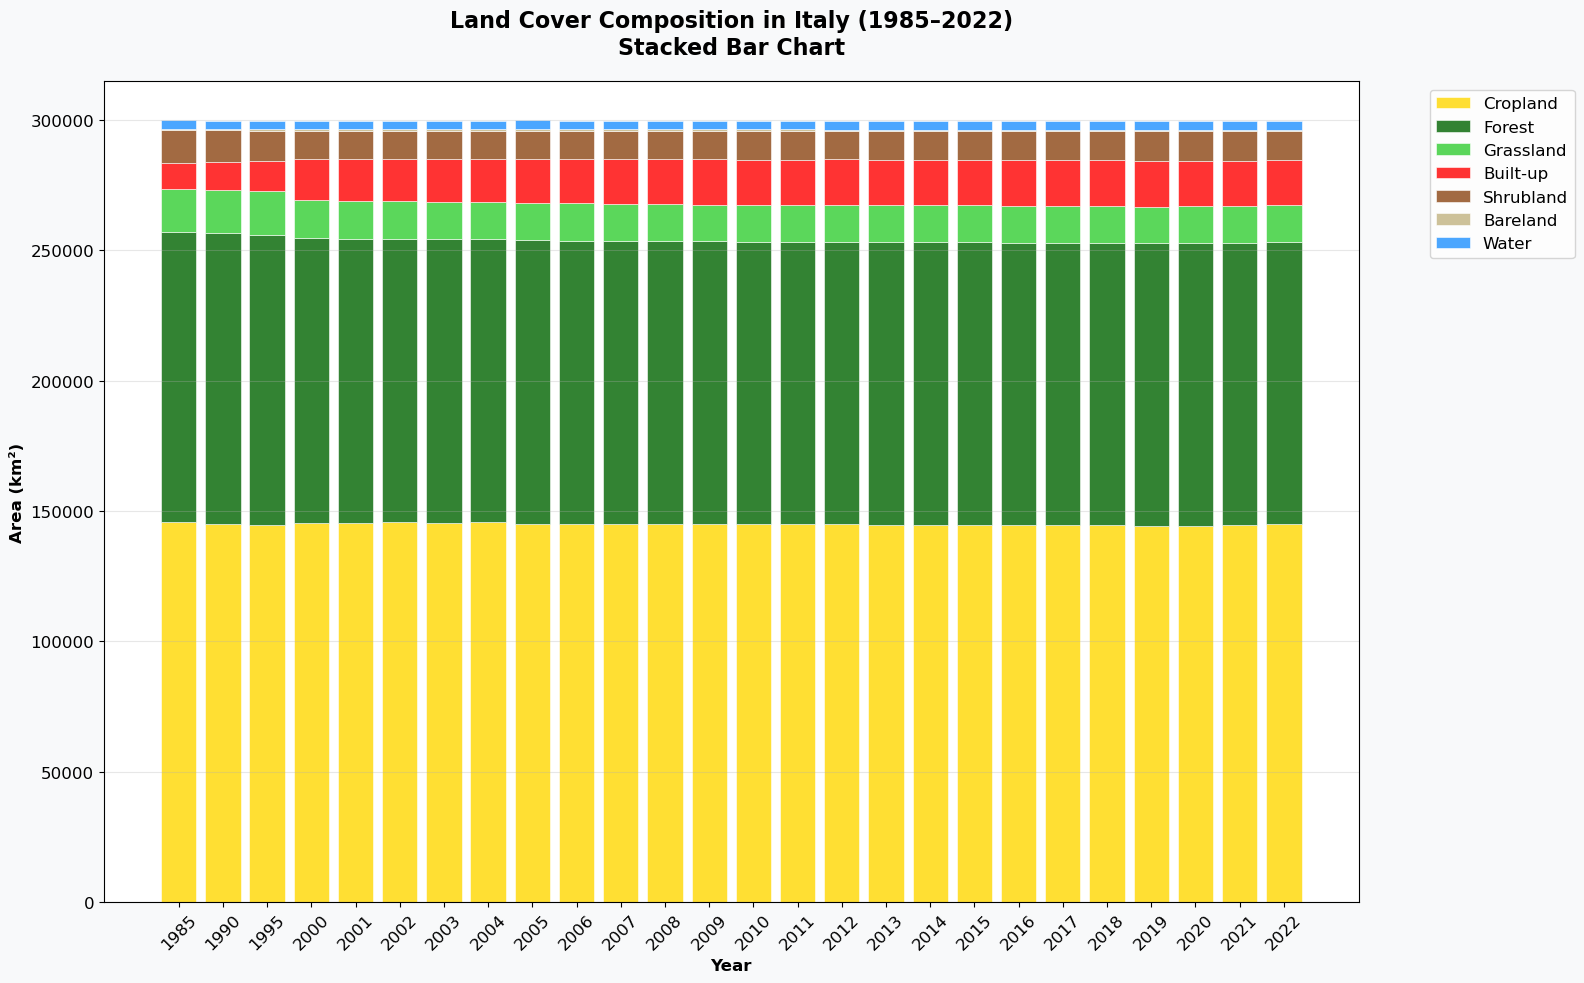

✅ Visualizations completed! PNG files saved in: /Users/ghulamabbaszafari/Downloads/CV/data/GLC_Stats


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import patheffects
import os

# ----------------------------
# 1. SETUP AND DATA LOADING
# ----------------------------
file_path = "/Users/ghulamabbaszafari/Downloads/CV/data/glc_italy_30m_stats_output2/glc_30m_detailed_stats_20250731_121834.csv"
output_dir = "/Users/ghulamabbaszafari/Downloads/CV/data/GLC_Stats"

# Create directory if missing
os.makedirs(output_dir, exist_ok=True)

df = pd.read_csv(file_path)

# Ensure Year is integer
df['Year'] = df['Year'].astype(int)

# --- Period Check ---
print("Data period covered:")
print("Start Year:", df['Year'].min())
print("End Year:  ", df['Year'].max())

print("\nIndex details:")
print(df.index)

# --- Check missing years ---
all_years = set(range(df['Year'].min(), df['Year'].max() + 1))
missing_years = sorted(all_years - set(df['Year'].unique()))
print("\nMissing years in dataset:", missing_years)
print("⚠️ Note: Expected (every 5 years until 2000, then annual).")

# ----------------------------
# 2. COLOR SCHEME (GLC CLASSES)
# ----------------------------
color_map = {
    'Shrubland': '#8b4513',          
    'Grassland': '#32cd32',          
    'Cropland': '#ffd700',           
    'Wetland': '#4682b4',            
    'Lichens and mosses': '#a9cda9', 
    'Bareland': '#c2b280',           
    'Built-up': '#ff0000',           
    'Water': '#1e90ff',              
    'Permanent ice and Snow': '#b0c4de',  
    'Forest': '#006400',             
    'No data': '#ffffff'             
}

# ----------------------------
# 3. PIE CHARTS (1985 vs 2022)
# ----------------------------
def create_stylish_pie_charts():
    data_1985 = df[df['Year'] == 1985]
    data_2022 = df[df['Year'] == 2022]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['font.size'] = 12
    
    for ax, year, data in zip([ax1, ax2], [1985, 2022], [data_1985, data_2022]):
        labels = data['Label'].tolist()
        sizes = data['Area_km2'].tolist()
        colors = [color_map.get(label, '#cccccc') for label in labels]
        explode = [0.05 if size > max(sizes)*0.5 else 0 for size in sizes]

        wedges, texts, autotexts = ax.pie(
            sizes, colors=colors, autopct='%1.1f%%', startangle=90,
            explode=explode, shadow=True,
            textprops={'fontsize': 9, 'fontweight': 'bold'}
        )
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
            autotext.set_path_effects([patheffects.withStroke(linewidth=2, foreground='black')])
        
        ax.set_title(f'Land Cover Distribution - {year}\nGLC_FCS30D 30m Data', 
                     fontsize=15, fontweight='bold', pad=15)
    
    # Legend
    all_labels = sorted(set(data_1985['Label']) | set(data_2022['Label']))
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                  markerfacecolor=color_map.get(label, '#cccccc'), 
                                  markersize=10, label=label) for label in all_labels]
    fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(1.15, 0.5),
               fontsize=11, title="Land Cover Classes", title_fontsize=12)
    
    # Main title
    fig.suptitle('Land Cover Composition in Italy: 1985 vs 2022 (GLC_FCS30D)', 
                 fontsize=20, fontweight='bold', y=1.02)
    
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])
    save_path = os.path.join(output_dir, "italy_glc_landcover_pie_charts.png")
    plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='#f8f9fa')
    plt.show()

# ----------------------------
# 4. DONUT CHART (2022)
# ----------------------------
def create_donut_chart():
    data_2022 = df[df['Year'] == 2022]
    fig, ax = plt.subplots(figsize=(16, 12))
    
    labels = data_2022['Label'].tolist()
    sizes = data_2022['Area_km2'].tolist()
    colors = [color_map.get(label, '#cccccc') for label in labels]
    
    wedges, texts, autotexts = ax.pie(
        sizes, colors=colors,
        autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',
        startangle=90, pctdistance=0.85,
        textprops={'fontsize': 10, 'fontweight': 'bold'}
    )
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    ax.add_artist(centre_circle)
    for autotext in autotexts:
        autotext.set_color('darkblue')
        autotext.set_path_effects([patheffects.withStroke(linewidth=1, foreground='white')])
    ax.axis('equal')
    
    total_area = sum(sizes)
    plt.text(0, 0, f'Total Area:\n{total_area:,.0f} km²', 
             ha='center', va='center', fontsize=14, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=1'))
    
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                  markerfacecolor=color_map.get(label, '#cccccc'),
                                  markersize=10, label=label) for label in labels]
    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5),
              fontsize=11, title="Land Cover Classes", title_fontsize=12)
    
    plt.title('Italy Land Cover Distribution - 2022\nGLC_FCS30D 30m Data', 
              fontsize=18, fontweight='bold', pad=25, y=1.05)
    
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    save_path = os.path.join(output_dir, "italy_glc_landcover_donut_2022.png")
    plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='#f8f9fa')
    plt.show()

# ----------------------------
# 5. MULTIPLE YEAR PIES
# ----------------------------
def create_multiple_year_pies():
    selected_years = [1985, 1995, 2005, 2022]
    fig, axes = plt.subplots(2, 2, figsize=(20, 18))
    axes = axes.flatten()
    
    for i, year in enumerate(selected_years):
        year_data = df[df['Year'] == year]
        labels = year_data['Label'].tolist()
        sizes = year_data['Area_km2'].tolist()
        colors = [color_map.get(label, '#cccccc') for label in labels]
        wedges, texts, autotexts = axes[i].pie(
            sizes, colors=colors, startangle=90, shadow=True, autopct=''
        )
        total = sum(sizes)
        for j, (wedge, size) in enumerate(zip(wedges, sizes)):
            if size / total > 0.03:
                angle = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
                x = 0.7 * np.cos(np.deg2rad(angle))
                y = 0.7 * np.sin(np.deg2rad(angle))
                percentage = (size / total) * 100
                axes[i].text(x, y, f'{percentage:.1f}%', ha='center', va='center',
                             fontweight='bold', fontsize=10,
                             bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9))
        axes[i].set_title(f'Land Cover - {year}\nTotal: {total:,.0f} km²',
                          fontsize=14, fontweight='bold', pad=15)
        axes[i].set_aspect('equal')
    
    unique_labels = list(df['Label'].unique())
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                                  markerfacecolor=color_map.get(label, '#cccccc'),
                                  markersize=10, label=label) for label in unique_labels]
    fig.legend(handles=legend_elements, loc="center right", bbox_to_anchor=(1.15, 0.5),
               fontsize=11, title="Land Cover Classes", title_fontsize=12)
    
    fig.suptitle('Land Cover Evolution in Italy (1985–2022)\nGLC_FCS30D 30m Data',
                 fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])
    save_path = os.path.join(output_dir, "italy_glc_landcover_multiple_years.png")
    plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='#f8f9fa')
    plt.show()

# ----------------------------
# 6. STACKED BAR PLOT
# ----------------------------
def create_landcover_bar_plot():
    pivot_df = df.pivot_table(index='Year', columns='Label', values='Area_km2', aggfunc='sum')
    main_classes = ['Cropland', 'Forest', 'Grassland', 'Built-up', 'Shrubland', 'Bareland', 'Water']
    pivot_df = pivot_df[[c for c in main_classes if c in pivot_df.columns]]
    
    fig, ax = plt.subplots(figsize=(16, 10))
    years = pivot_df.index
    x = np.arange(len(years))
    bottom = np.zeros(len(years))
    
    for class_name in pivot_df.columns:
        values = pivot_df[class_name].values
        ax.bar(x, values, label=class_name, color=color_map.get(class_name, '#cccccc'),
               bottom=bottom, alpha=0.8, edgecolor='white', linewidth=0.5)
        bottom += values
    
    ax.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax.set_ylabel('Area (km²)', fontsize=12, fontweight='bold')
    ax.set_title('Land Cover Composition in Italy (1985–2022)\nStacked Bar Chart',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(years, rotation=45)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    save_path = os.path.join(output_dir, "italy_glc_landcover_stacked_bars.png")
    plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='#f8f9fa')
    plt.show()

# ----------------------------
# 7. RUN VISUALIZATIONS
# ----------------------------
if __name__ == "__main__":
    print("Creating GLC_FCS30D land cover visualizations...")
    plt.style.use('default')
    plt.rcParams['figure.facecolor'] = '#f8f9fa'
    
    create_stylish_pie_charts()
    create_donut_chart()
    create_multiple_year_pies()
    create_landcover_bar_plot()
    
    print(f"✅ Visualizations completed! PNG files saved in: {output_dir}")




Data period covered:
Start Year: 1985
End Year:   2022

Index details:
RangeIndex(start=0, stop=257, step=1)

Missing years in dataset: [1986, 1987, 1988, 1989, 1991, 1992, 1993, 1994, 1996, 1997, 1998, 1999]
⚠️ Note: Expected (every 5 years until 2000, then annual).
Creating GLC_FCS30D land cover visualizations...


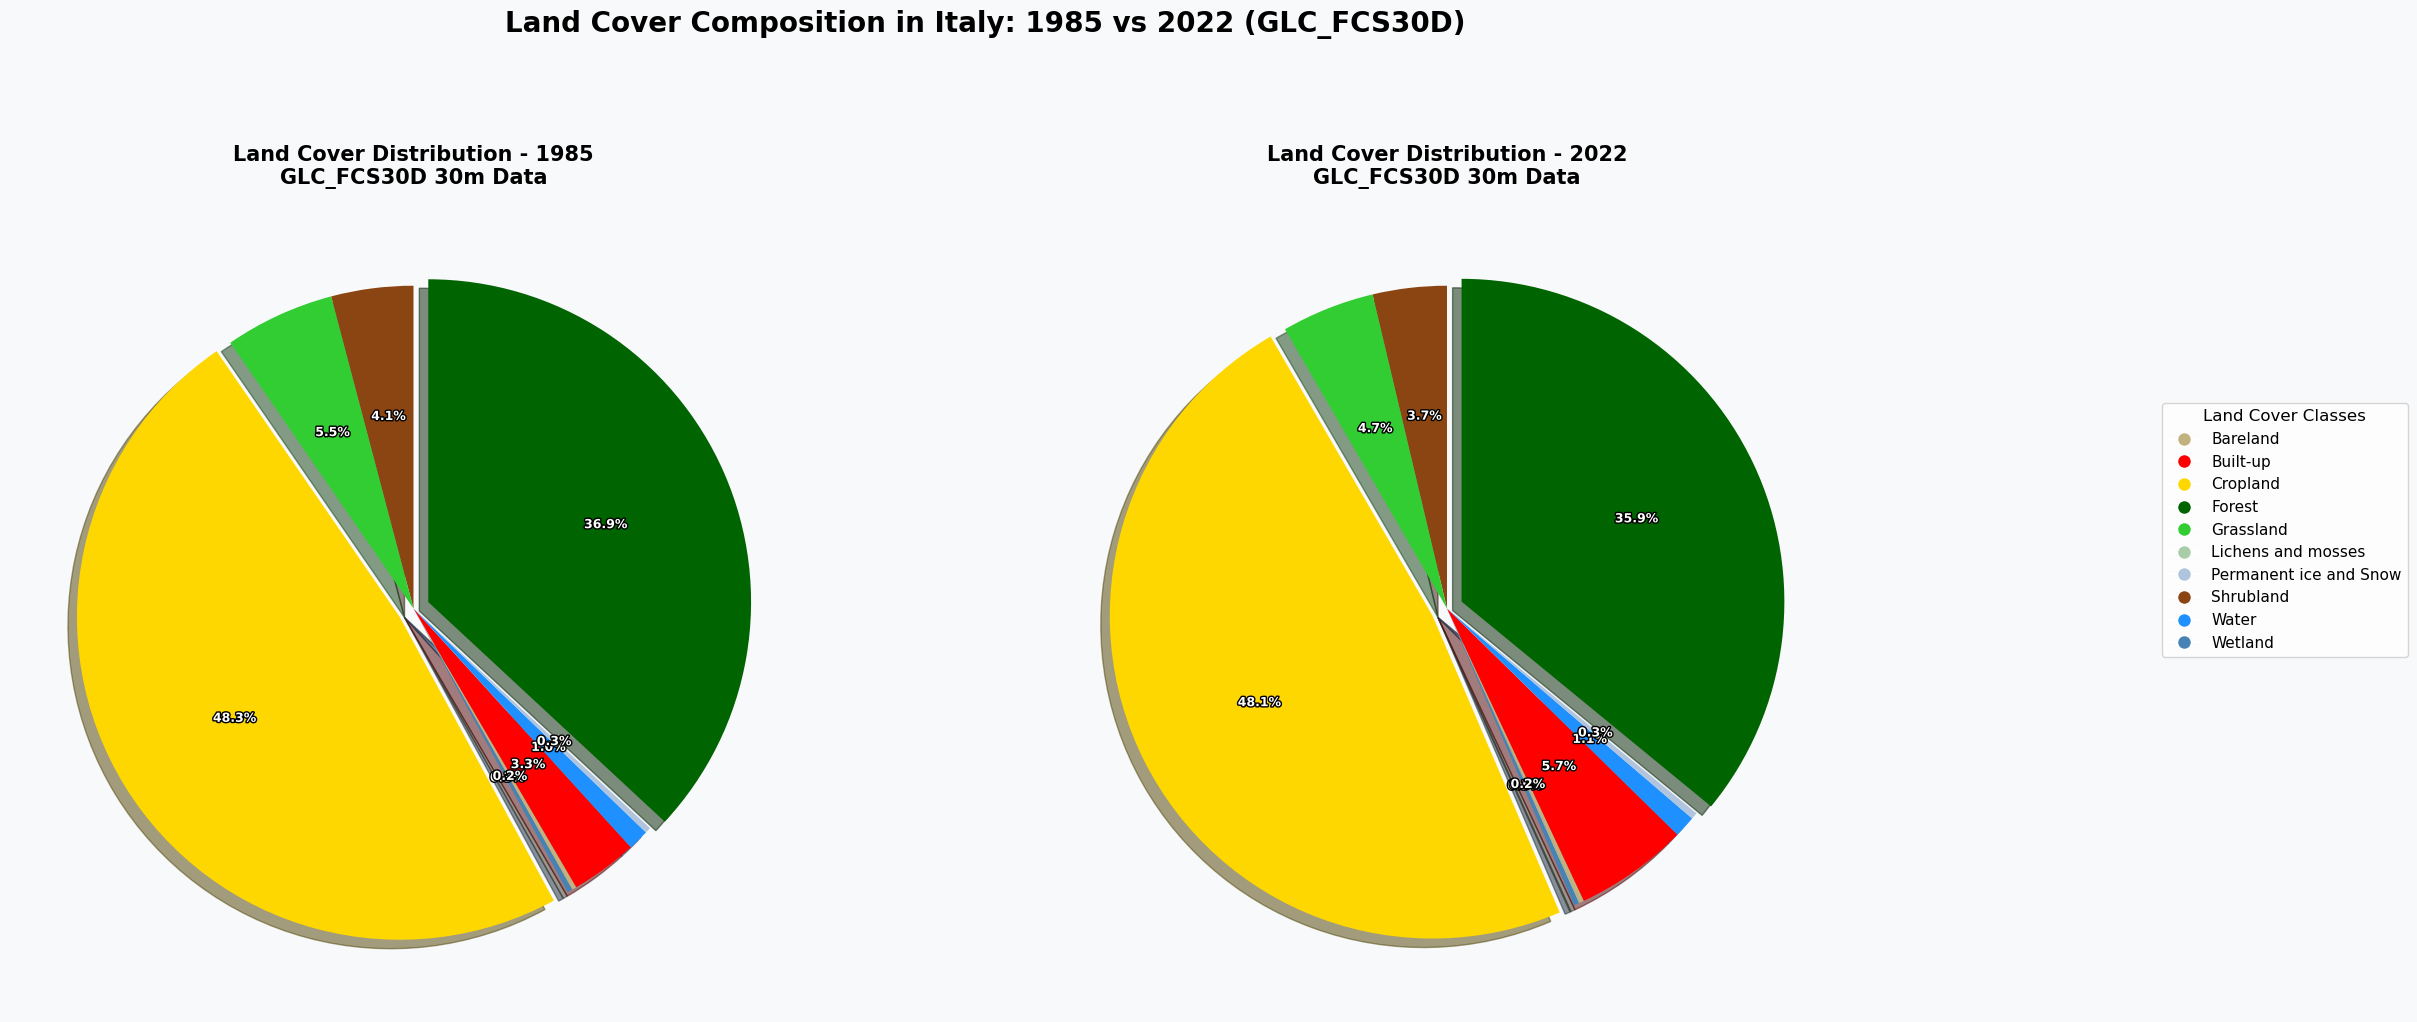

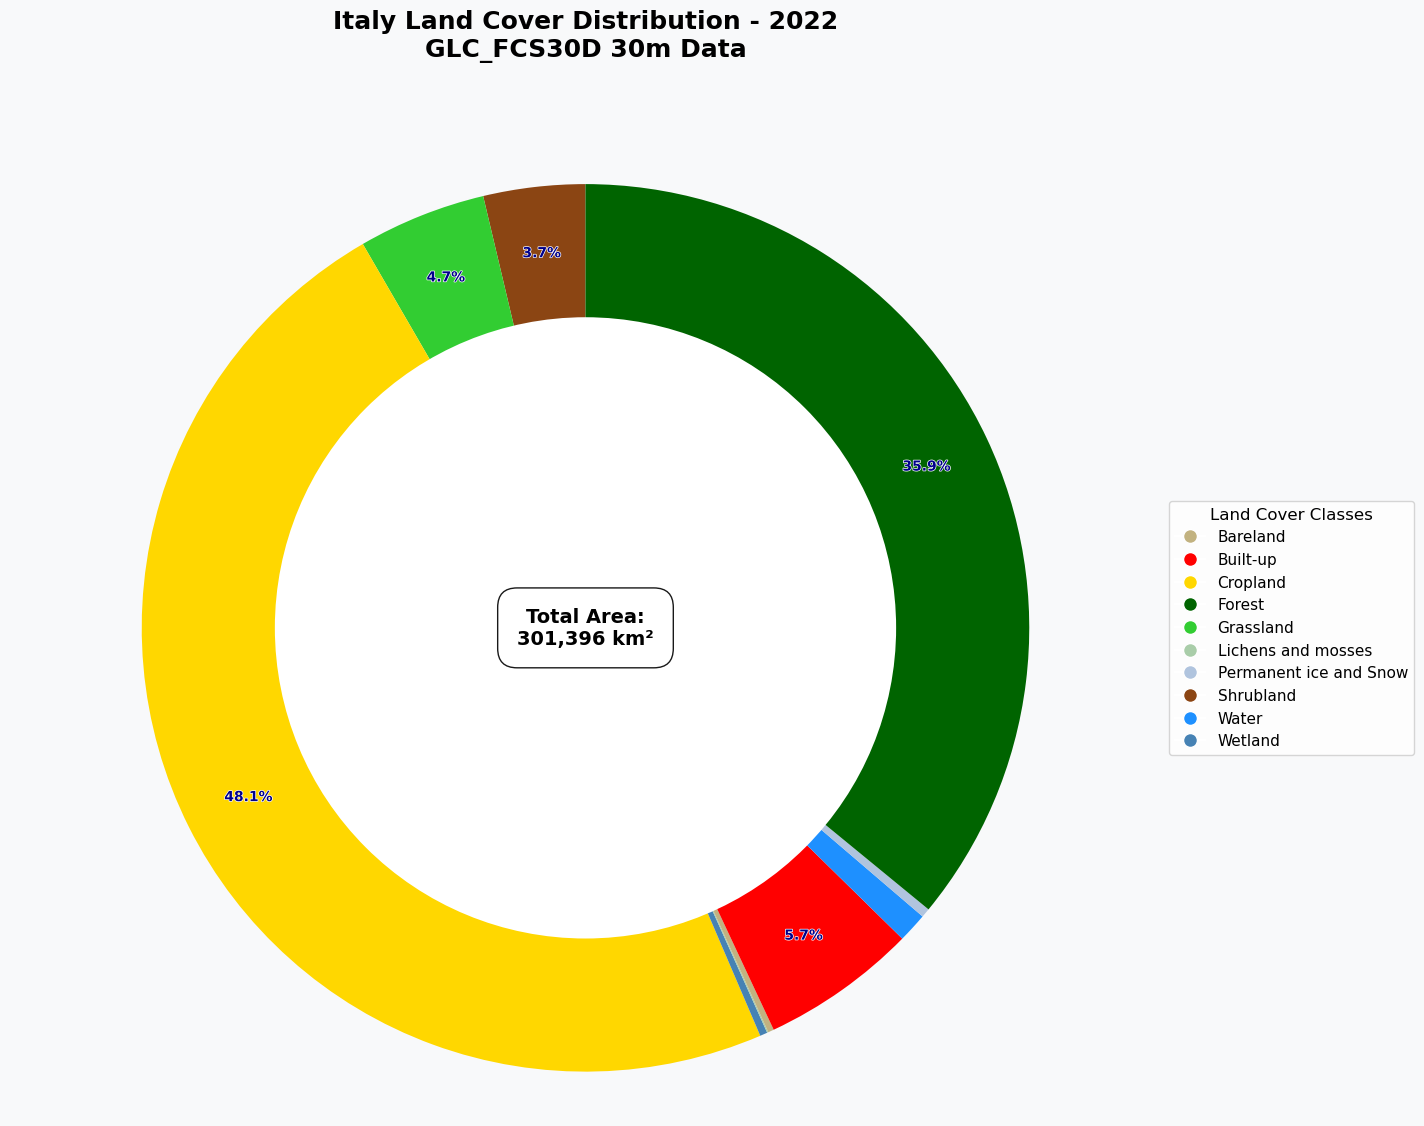

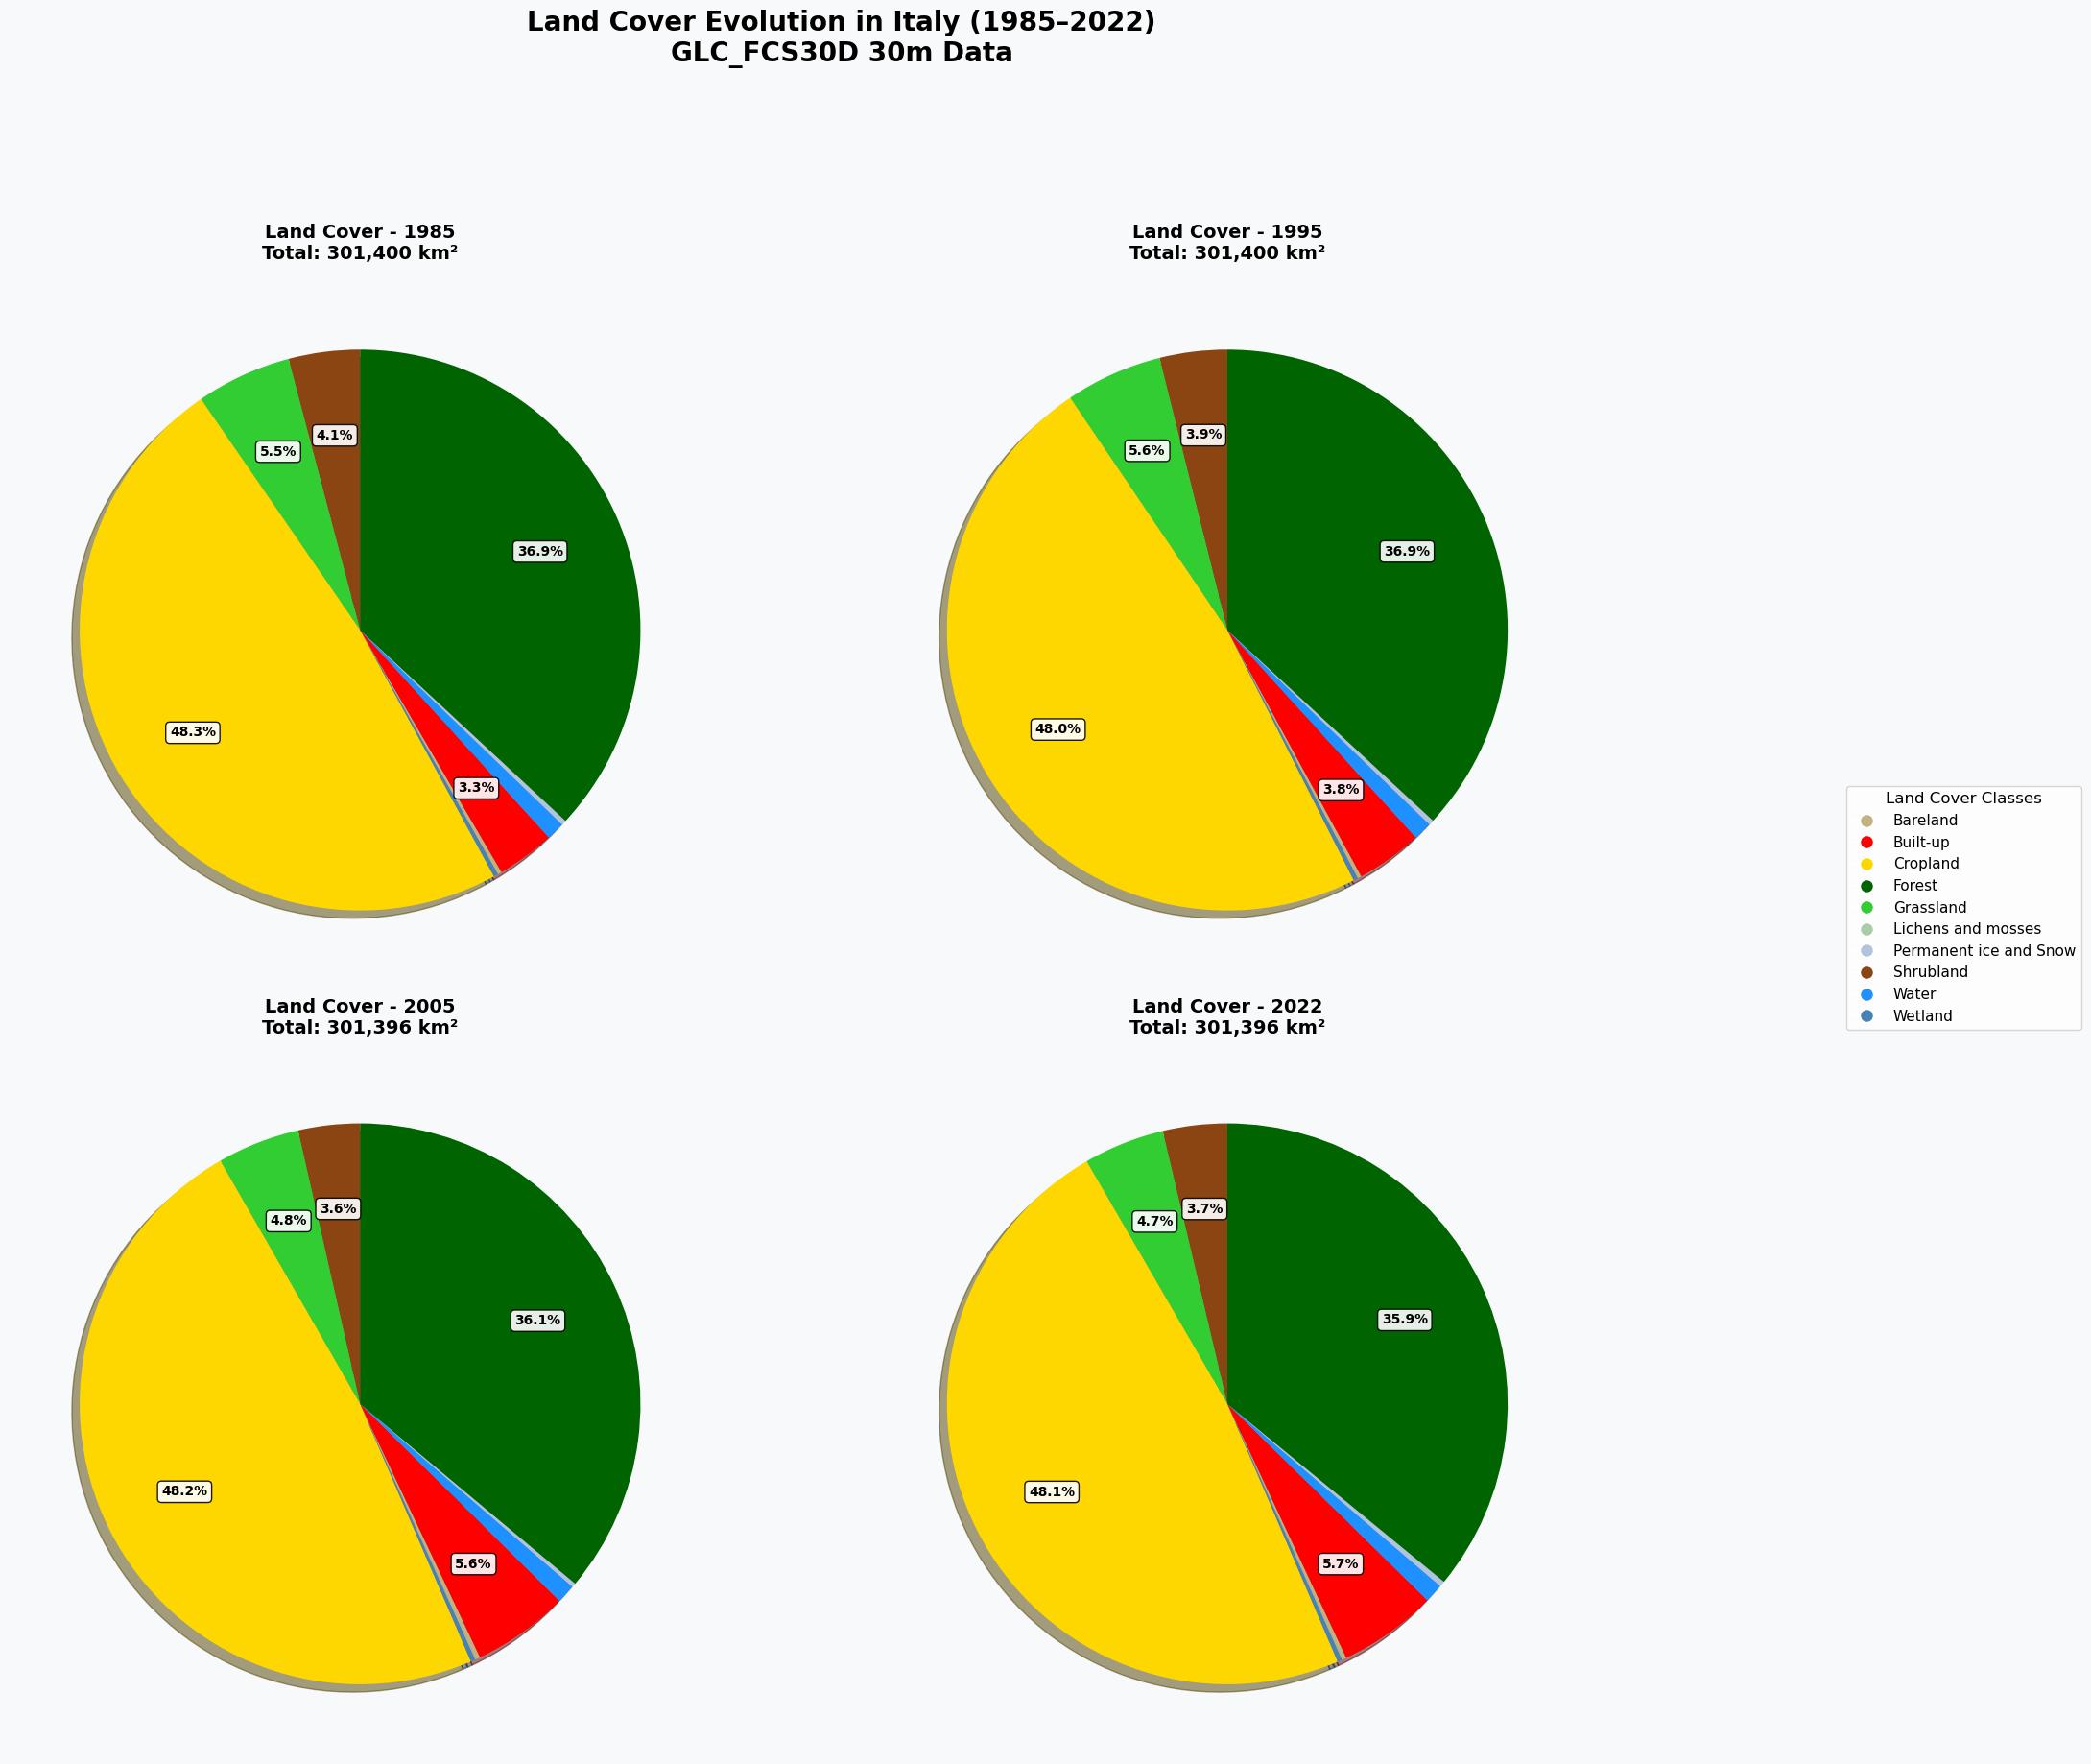

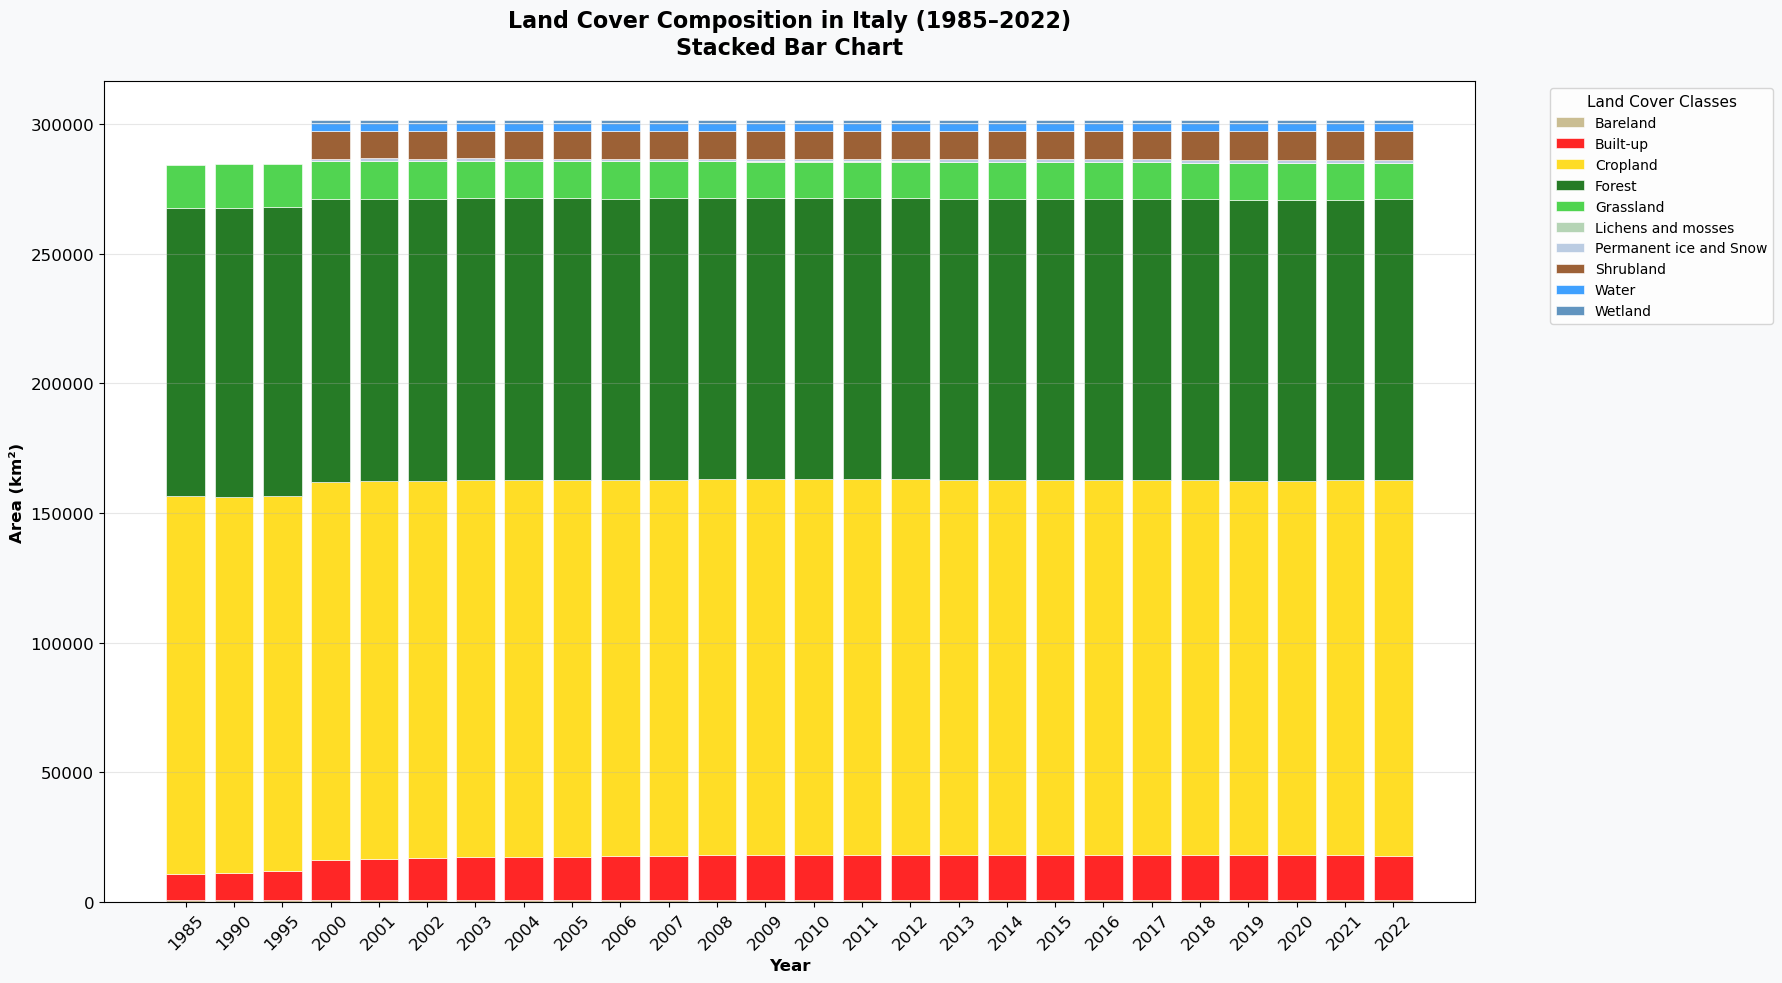

✅ Visualizations completed! PNG files saved in: /Users/ghulamabbaszafari/Downloads/CV/data/GLC_Stats


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import patheffects
import os

# ----------------------------
# 1. SETUP AND DATA LOADING
# ----------------------------
file_path = "/Users/ghulamabbaszafari/Downloads/CV/data/glc_italy_30m_stats_output2/glc_30m_detailed_stats_20250731_121834.csv"
output_dir = "/Users/ghulamabbaszafari/Downloads/CV/data/GLC_Stats"

# Create directory if missing
os.makedirs(output_dir, exist_ok=True)

df = pd.read_csv(file_path)

# Ensure Year is integer
df['Year'] = df['Year'].astype(int)

# --- Period Check ---
print("Data period covered:")
print("Start Year:", df['Year'].min())
print("End Year:  ", df['Year'].max())

print("\nIndex details:")
print(df.index)

# --- Check missing years ---
all_years = set(range(df['Year'].min(), df['Year'].max() + 1))
missing_years = sorted(all_years - set(df['Year'].unique()))
print("\nMissing years in dataset:", missing_years)
print("⚠️ Note: Expected (every 5 years until 2000, then annual).")

# ----------------------------
# 2. COLOR SCHEME (GLC CLASSES)
# ----------------------------
color_map = {
    'Shrubland': '#8b4513',          
    'Grassland': '#32cd32',          
    'Cropland': '#ffd700',           
    'Wetland': '#4682b4',            
    'Lichens and mosses': '#a9cda9', 
    'Bareland': '#c2b280',           
    'Built-up': '#ff0000',           
    'Water': '#1e90ff',              
    'Permanent ice and Snow': '#b0c4de',  
    'Forest': '#006400',             
    'No data': '#ffffff'             
}

# Collect all unique labels in dataset
all_classes = sorted(df['Label'].unique())

# ----------------------------
# 3. PIE CHARTS (1985 vs 2022)
# ----------------------------
def create_stylish_pie_charts():
    data_1985 = df[df['Year'] == 1985]
    data_2022 = df[df['Year'] == 2022]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['font.size'] = 12
    
    for ax, year, data in zip([ax1, ax2], [1985, 2022], [data_1985, data_2022]):
        labels = data['Label'].tolist()
        sizes = data['Area_km2'].tolist()
        colors = [color_map.get(label, '#cccccc') for label in labels]
        explode = [0.05 if size > max(sizes)*0.5 else 0 for size in sizes]

        wedges, texts, autotexts = ax.pie(
            sizes, colors=colors, autopct='%1.1f%%', startangle=90,
            explode=explode, shadow=True,
            textprops={'fontsize': 9, 'fontweight': 'bold'}
        )
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
            autotext.set_path_effects([patheffects.withStroke(linewidth=2, foreground='black')])
        
        ax.set_title(f'Land Cover Distribution - {year}\nGLC_FCS30D 30m Data', 
                     fontsize=15, fontweight='bold', pad=15)
    
    # Legend with ALL classes
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                  markerfacecolor=color_map.get(label, '#cccccc'), 
                                  markersize=10, label=label) for label in all_classes]
    fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(1.15, 0.5),
               fontsize=11, title="Land Cover Classes", title_fontsize=12)
    
    # Main title
    fig.suptitle('Land Cover Composition in Italy: 1985 vs 2022 (GLC_FCS30D)', 
                 fontsize=20, fontweight='bold', y=1.02)
    
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])
    save_path = os.path.join(output_dir, "italy_glc_landcover_pie_charts.png")
    plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='#f8f9fa')
    plt.show()

# ----------------------------
# 4. DONUT CHART (2022)
# ----------------------------
def create_donut_chart():
    data_2022 = df[df['Year'] == 2022]
    fig, ax = plt.subplots(figsize=(16, 12))
    
    labels = data_2022['Label'].tolist()
    sizes = data_2022['Area_km2'].tolist()
    colors = [color_map.get(label, '#cccccc') for label in labels]
    
    wedges, texts, autotexts = ax.pie(
        sizes, colors=colors,
        autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',
        startangle=90, pctdistance=0.85,
        textprops={'fontsize': 10, 'fontweight': 'bold'}
    )
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    ax.add_artist(centre_circle)
    for autotext in autotexts:
        autotext.set_color('darkblue')
        autotext.set_path_effects([patheffects.withStroke(linewidth=1, foreground='white')])
    ax.axis('equal')
    
    total_area = sum(sizes)
    plt.text(0, 0, f'Total Area:\n{total_area:,.0f} km²', 
             ha='center', va='center', fontsize=14, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=1'))
    
    # Legend with ALL classes
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                  markerfacecolor=color_map.get(label, '#cccccc'),
                                  markersize=10, label=label) for label in all_classes]
    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5),
              fontsize=11, title="Land Cover Classes", title_fontsize=12)
    
    plt.title('Italy Land Cover Distribution - 2022\nGLC_FCS30D 30m Data', 
              fontsize=18, fontweight='bold', pad=25, y=1.05)
    
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    save_path = os.path.join(output_dir, "italy_glc_landcover_donut_2022.png")
    plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='#f8f9fa')
    plt.show()

# ----------------------------
# 5. MULTIPLE YEAR PIES
# ----------------------------
def create_multiple_year_pies():
    selected_years = [1985, 1995, 2005, 2022]
    fig, axes = plt.subplots(2, 2, figsize=(20, 18))
    axes = axes.flatten()
    
    for i, year in enumerate(selected_years):
        year_data = df[df['Year'] == year]
        labels = year_data['Label'].tolist()
        sizes = year_data['Area_km2'].tolist()
        colors = [color_map.get(label, '#cccccc') for label in labels]
        wedges, texts, autotexts = axes[i].pie(
            sizes, colors=colors, startangle=90, shadow=True, autopct=''
        )
        total = sum(sizes)
        for j, (wedge, size) in enumerate(zip(wedges, sizes)):
            if size / total > 0.03:
                angle = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
                x = 0.7 * np.cos(np.deg2rad(angle))
                y = 0.7 * np.sin(np.deg2rad(angle))
                percentage = (size / total) * 100
                axes[i].text(x, y, f'{percentage:.1f}%', ha='center', va='center',
                             fontweight='bold', fontsize=10,
                             bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9))
        axes[i].set_title(f'Land Cover - {year}\nTotal: {total:,.0f} km²',
                          fontsize=14, fontweight='bold', pad=15)
        axes[i].set_aspect('equal')
    
    # Legend with ALL classes
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                                  markerfacecolor=color_map.get(label, '#cccccc'),
                                  markersize=10, label=label) for label in all_classes]
    fig.legend(handles=legend_elements, loc="center right", bbox_to_anchor=(1.15, 0.5),
               fontsize=11, title="Land Cover Classes", title_fontsize=12)
    
    fig.suptitle('Land Cover Evolution in Italy (1985–2022)\nGLC_FCS30D 30m Data',
                 fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])
    save_path = os.path.join(output_dir, "italy_glc_landcover_multiple_years.png")
    plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='#f8f9fa')
    plt.show()

# ----------------------------
# 6. STACKED BAR PLOT (ALL CLASSES)
# ----------------------------
def create_landcover_bar_plot():
    pivot_df = df.pivot_table(index='Year', columns='Label', values='Area_km2', aggfunc='sum')

    fig, ax = plt.subplots(figsize=(18, 10))
    years = pivot_df.index
    x = np.arange(len(years))
    bottom = np.zeros(len(years))

    for class_name in pivot_df.columns:
        values = pivot_df[class_name].values
        ax.bar(
            x, values,
            label=class_name,
            color=color_map.get(class_name, '#cccccc'),
            bottom=bottom,
            alpha=0.85,
            edgecolor='white',
            linewidth=0.5
        )
        bottom += values

    ax.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax.set_ylabel('Area (km²)', fontsize=12, fontweight='bold')
    ax.set_title('Land Cover Composition in Italy (1985–2022)\nStacked Bar Chart',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(years, rotation=45)

    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10,
              title="Land Cover Classes", title_fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(output_dir, "italy_glc_landcover_stacked_bars.png")
    plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='#f8f9fa')
    plt.show()

# ----------------------------
# 7. RUN VISUALIZATIONS
# ----------------------------
if __name__ == "__main__":
    print("Creating GLC_FCS30D land cover visualizations...")
    plt.style.use('default')
    plt.rcParams['figure.facecolor'] = '#f8f9fa'
    
    create_stylish_pie_charts()
    create_donut_chart()
    create_multiple_year_pies()
    create_landcover_bar_plot()
    
    print(f"✅ Visualizations completed! PNG files saved in: {output_dir}")
